# Spain Power System — AC OPF Results

Reads the CSV files saved by `run_opf.jl` from the `results/` directory and produces:
- OPF summary statistics
- Fuel-mix dispatch bar chart
- Installed capacity vs. dispatch comparison
- Generator dispatch scatter (capacity vs. dispatch, coloured by fuel)
- Reactive power procurement by fuel and P–Q operating points
- Bus voltage magnitude distribution
- Reactive branch flow analysis
- Branch loading distribution
- Congested branches

**Run `julia run_opf.jl` first** to generate the result files.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
from plotly.subplots import make_subplots
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

RESULTS = Path('results')

# Network map snapshot. Set MAP_DATE to None to use the first available result date.
MAP_DATE = None
MAP_HOUR = 0
MAP_MIN_LOADING_PCT = 0.0


pio.templates.default = 'plotly_white'

def save_plotly(fig, filename):
    output_path = RESULTS / filename
    fig.write_html(output_path, include_plotlyjs='cdn', full_html=True)
    return output_path
FUEL_COLORS = {
    'Wind':                '#4CAF50',
    'Solar':               '#FFC107',
    'Hydro':               '#2196F3',
    'Nuclear':             '#9C27B0',
    'Gas':                 '#F44336',
    'Coal':                '#212121',
    'Biomass':             '#795548',
    'Oil':                 '#607D8B',
    'CrossBorder':         '#6C757D',
    'Electricity Storage': '#00BCD4',
    'Slack':               '#BDBDBD',
}

In [2]:
# Load result CSVs
def load_results():
    missing = [f for f in ['summary.csv', 'gen_dispatch.csv', 'fuel_mix.csv', 'branch_flows.csv']
               if not (RESULTS / f).exists()]
    if missing:
        raise FileNotFoundError(
            f"Missing result files: {missing}\n"
            "Run  julia run_opf.jl  first to generate them."
        )
    return (
        pd.read_csv(RESULTS / 'summary.csv'),
        pd.read_csv(RESULTS / 'gen_dispatch.csv'),
        pd.read_csv(RESULTS / 'fuel_mix.csv'),
        pd.read_csv(RESULTS / 'branch_flows.csv'),
    )

summary_df, gen_df, fuel_df, branch_df = load_results()
print('Result files loaded successfully.')

Result files loaded successfully.


## Summary

In [3]:
n_hours = summary_df[['date', 'hour']].drop_duplicates().shape[0]
solved_mask = summary_df['status'].isin(['OPTIMAL', 'LOCALLY_SOLVED'])
print(f"{'='*55}")
print(f"AC OPF Summary — {len(summary_df['date'].unique())} days, {n_hours} hourly snapshots")
print(f"{'='*55}")

for date, grp in summary_df.groupby('date'):
    solved = grp[solved_mask & (grp['date'] == date)]
    label  = pd.Timestamp(date).strftime('%d %B %Y')
    cong_per_hour = (branch_df[branch_df['date'] == date]
                     .groupby('hour')
                     .apply(lambda x: (x['loading_pct'] > 90).sum()))
    print(f"\n  {label}")
    print(f"    Hours solved     : {len(solved)} / {len(grp)}")
    print(f"    Avg system cost  : {solved['objective_eur_h'].mean():>13,.0f} €/h")
    print(f"    Load range       : {solved['total_load_mw'].min():>7,.0f} – "
          f"{solved['total_load_mw'].max():,.0f} MW")
    print(f"    Avg generation   : {solved['total_gen_mw'].mean():>13,.1f} MW")
    print(f"    Congested lines  : avg {cong_per_hour.mean():.0f}, "
          f"max {cong_per_hour.max():.0f} per hour  (>90% apparent loading)")

print(f"\n{'='*55}")

AC OPF Summary — 2 days, 48 hourly snapshots

  08 July 2024
    Hours solved     : 24 / 24
    Avg system cost  :       139,913 €/h
    Load range       :  20,944 – 39,222 MW
    Avg generation   :      31,571.0 MW
    Congested lines  : avg 12, max 36 per hour  (>90% apparent loading)

  02 December 2024
    Hours solved     : 24 / 24
    Avg system cost  :       469,052 €/h
    Load range       :  21,118 – 34,439 MW
    Avg generation   :      29,479.0 MW
    Congested lines  : avg 4, max 7 per hour  (>90% apparent loading)



## Fuel Mix Dispatch

In [4]:
# Average hourly dispatch per fuel, per day
avg_fuel = (fuel_df.groupby(['date', 'fuel'])['dispatch_mw']
            .mean().reset_index())

days = sorted(avg_fuel['date'].unique())
fuel_ord = (avg_fuel.groupby('fuel')['dispatch_mw'].sum()
            .sort_values(ascending=True).index.tolist())

specs = [[{'type': 'bar'}] + [{'type': 'domain'} for _ in days]]
fig = make_subplots(
    rows=1, cols=1 + len(days), specs=specs,
    column_widths=[0.42] + [0.29] * len(days),
    subplot_titles=['Fuel Mix - Average Hourly Dispatch'] +
                   [f"Generation Mix - {pd.Timestamp(day).strftime('%d %b')} (%)" for day in days],
)

for i, day in enumerate(days):
    vals = [avg_fuel[(avg_fuel['date'] == day) & (avg_fuel['fuel'] == f)]['dispatch_mw'].sum() / 1e3
            for f in fuel_ord]
    fig.add_trace(
        go.Bar(
            y=fuel_ord, x=vals, orientation='h',
            marker_color=[FUEL_COLORS.get(f, '#90A4AE') for f in fuel_ord],
            opacity=0.9 if i == 0 else 0.5,
            name=pd.Timestamp(day).strftime('%d %b'),
            hovertemplate='Fuel: %{y}<br>Avg dispatch: %{x:.2f} GW<extra>%{fullData.name}</extra>',
            showlegend=True,
        ),
        row=1, col=1,
    )

pie_fuel_order = (fuel_df.groupby('fuel')['dispatch_mw'].sum()
                  .reset_index().query('dispatch_mw > 1')
                  .sort_values('dispatch_mw', ascending=False)['fuel'].tolist())

for j, day in enumerate(days, start=2):
    day_total = (fuel_df[fuel_df['date'] == day]
                 .groupby('fuel')['dispatch_mw'].sum()
                 .reindex(pie_fuel_order, fill_value=0)
                 .reset_index().rename(columns={'index': 'fuel'})
                 .query('dispatch_mw > 1'))
    fig.add_trace(
        go.Pie(
            labels=day_total['fuel'], values=day_total['dispatch_mw'],
            marker_colors=[FUEL_COLORS.get(f, '#90A4AE') for f in day_total['fuel']],
            textinfo='percent', hovertemplate='%{label}<br>%{value:,.0f} MWh<br>%{percent}<extra></extra>',
            showlegend=(j == 2),
        ),
        row=1, col=j,
    )

fig.update_layout(
    height=560, barmode='group', title='Fuel Mix Dispatch',
    legend_title_text='Day / fuel', margin=dict(l=80, r=30, t=80, b=40),
)
fig.update_xaxes(title_text='Avg Hourly Dispatch (GW)', row=1, col=1)
fig.update_yaxes(autorange='reversed', row=1, col=1)
save_plotly(fig, 'fuel_mix.html')
fig.show()


## Installed Capacity vs. Dispatch

In [5]:
# Average dispatch per fuel across all hours and both days
avg_fuel_all = (fuel_df.groupby('fuel')
                .agg(dispatch_mw=('dispatch_mw', 'mean'),
                     capacity_mw=('capacity_mw', 'first'))
                .reset_index()
                .sort_values('dispatch_mw', ascending=False))
avg_fuel_all = avg_fuel_all[avg_fuel_all['capacity_mw'] > 1].copy()

# Hide installed capacity for Slack bus as it is artificially large
avg_fuel_all.loc[avg_fuel_all['fuel'] == 'Slack', 'capacity_mw'] = np.nan

fig = go.Figure()
fig.add_trace(go.Bar(
    x=avg_fuel_all['fuel'], y=avg_fuel_all['capacity_mw'] / 1e3,
    name='Installed Capacity', marker_color='steelblue', opacity=0.75,
    hovertemplate='Fuel: %{x}<br>Capacity: %{y:.2f} GW<extra></extra>',
))
fig.add_trace(go.Bar(
    x=avg_fuel_all['fuel'], y=avg_fuel_all['dispatch_mw'] / 1e3,
    name='Avg Hourly Dispatch', marker_color='tomato', opacity=0.9,
    hovertemplate='Fuel: %{x}<br>Avg dispatch: %{y:.2f} GW<extra></extra>',
))
fig.update_layout(
    title='Installed Capacity vs. Average Hourly Dispatch by Fuel',
    xaxis_title='Fuel', yaxis_title='Power (GW)', barmode='group',
    height=520, margin=dict(l=60, r=30, t=70, b=90),
)
fig.update_xaxes(tickangle=30)
save_plotly(fig, 'capacity_vs_dispatch.html')
fig.show()


## Top Dispatched Generators

In [6]:
top_n = 25
avg_gen = (gen_df[(gen_df['dispatch_mw'] > 0.5) & (gen_df['fuel'] != 'CrossBorder')]
           .groupby(['unit_name', 'fuel', 'capacity_mw'])
           .agg(dispatch_mw=('dispatch_mw', 'mean'),
                utilization_pct=('utilization_pct', 'mean'))
           .reset_index()
           .sort_values('dispatch_mw', ascending=False)
           .head(top_n))

avg_gen_plot = avg_gen.sort_values('dispatch_mw', ascending=True).copy()
fig = px.bar(
    avg_gen_plot, x='dispatch_mw', y='unit_name', color='fuel', orientation='h',
    color_discrete_map=FUEL_COLORS,
    custom_data=['utilization_pct', 'capacity_mw'],
    title=f'Top {top_n} Generators by Average Dispatch',
)
fig.update_traces(
    hovertemplate=(
        'Generator: %{y}<br>Avg dispatch: %{x:.1f} MW<br>'
        'Avg utilisation: %{customdata[0]:.0f}%<br>Capacity: %{customdata[1]:.1f} MW<extra>%{fullData.name}</extra>'
    )
)
fig.update_layout(
    xaxis_title='Average Dispatch (MW)', yaxis_title='',
    height=760, legend_title_text='Fuel', margin=dict(l=220, r=30, t=70, b=40),
)
save_plotly(fig, 'top_generators.html')
fig.show()


## Generator Capacity vs. Dispatch Scatter

In [7]:
# Average dispatch per generator across all hours and both days
avg_gen_scatter = (gen_df[(gen_df['capacity_mw'] > 0) &
                         (~gen_df['fuel'].isin(['Slack', 'CrossBorder']))]
                   .groupby(['unit_name', 'fuel', 'capacity_mw'])
                   ['dispatch_mw'].mean()
                   .reset_index())

fig = px.scatter(
    avg_gen_scatter, x='capacity_mw', y='dispatch_mw', color='fuel',
    color_discrete_map=FUEL_COLORS, hover_name='unit_name',
    labels={'capacity_mw': 'Installed Capacity (MW)', 'dispatch_mw': 'Average Dispatch (MW)'},
    title='Generator Capacity vs. Average Dispatch',
)
max_cap = avg_gen_scatter['capacity_mw'].max()
fig.add_trace(go.Scatter(
    x=[0, max_cap], y=[0, max_cap], mode='lines', name='100% utilisation',
    line=dict(color='black', dash='dash', width=1),
    hovertemplate='100% utilisation<extra></extra>',
))
fig.update_traces(marker=dict(size=8, opacity=0.7), selector=dict(mode='markers'))
fig.update_layout(height=650, legend_title_text='Fuel', margin=dict(l=60, r=30, t=70, b=50))
save_plotly(fig, 'gen_scatter.html')
fig.show()


## Branch Loading

In [8]:
n_snapshots = branch_df[['date', 'hour']].drop_duplicates().shape[0]
cong_summary = (branch_df[branch_df['loading_pct'] > 90]
                .groupby('branch_name')
                .agg(congested_hours=('loading_pct', 'count'),
                     max_loading=('loading_pct', 'max'))
                .reset_index()
                .sort_values('congested_hours', ascending=True)
                .tail(20))

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[f'Branch Loading Distribution - All {n_snapshots} Hourly Snapshots',
                    'Most Persistently Congested Branches (>90%)'],
    horizontal_spacing=0.16,
)
fig.add_trace(go.Histogram(
    x=branch_df['loading_pct'], nbinsx=60, name='Loading', marker_color='steelblue',
    hovertemplate='Loading bin: %{x}<br>Count: %{y}<extra></extra>',
), row=1, col=1)
fig.add_vline(x=90, line_color='red', line_dash='dash', line_width=1.5, row=1, col=1)

if len(cong_summary) > 0:
    fig.add_trace(go.Bar(
        x=cong_summary['congested_hours'], y=cong_summary['branch_name'], orientation='h',
        marker=dict(color=cong_summary['congested_hours'], colorscale='YlOrRd', colorbar=dict(title='Hours')),
        customdata=cong_summary['max_loading'], name='Congested hours',
        hovertemplate='Branch: %{y}<br>Hours congested: %{x}<br>Max loading: %{customdata:.1f}%<extra></extra>',
    ), row=1, col=2)
else:
    fig.add_annotation(text='No congested branches<br>(all below 90%)', x=0.75, y=0.5,
                       xref='paper', yref='paper', showarrow=False)

fig.update_xaxes(title_text='Loading (%)', row=1, col=1)
fig.update_yaxes(title_text='Count (branch x hour)', row=1, col=1)
fig.update_xaxes(title_text=f'Hours congested (out of {n_snapshots})', row=1, col=2)
fig.update_layout(height=560, showlegend=False, margin=dict(l=70, r=30, t=80, b=50))
save_plotly(fig, 'branch_loading.html')
fig.show()


## Reactive Power Procurement

In [9]:
gen_ac = gen_df[gen_df['fuel'] != 'Slack'].copy()

avg_q = (gen_ac.groupby('fuel')
         .agg(q_mvar=('dispatch_mvar', 'mean'),
              p_mw=('dispatch_mw', 'mean'))
         .reset_index()
         .sort_values('q_mvar'))
avg_q['pf'] = avg_q.apply(
    lambda r: r['p_mw'] / np.hypot(r['p_mw'], r['q_mvar']) if np.hypot(r['p_mw'], r['q_mvar']) > 0 else np.nan,
    axis=1,
)

pq = (gen_ac.groupby(['unit_name', 'fuel'])[['dispatch_mw', 'dispatch_mvar']]
      .mean().reset_index())

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Reactive Procurement by Fuel Type', 'Generator P-Q Operating Points'],
    horizontal_spacing=0.14,
)
fig.add_trace(go.Bar(
    y=avg_q['fuel'], x=avg_q['q_mvar'], orientation='h',
    marker_color=[FUEL_COLORS.get(f, '#90A4AE') for f in avg_q['fuel']],
    text=[f'PF={pf:.2f}' if pd.notna(pf) else '' for pf in avg_q['pf']], textposition='auto',
    customdata=np.column_stack([avg_q['p_mw'], avg_q['pf']]), name='Avg Q',
    hovertemplate='Fuel: %{y}<br>Avg Q: %{x:.1f} MVAr<br>Avg P: %{customdata[0]:.1f} MW<br>PF: %{customdata[1]:.2f}<extra></extra>',
), row=1, col=1)
fig.add_vline(x=0, line_color='black', line_width=1, row=1, col=1)

for fuel, grp in pq.groupby('fuel'):
    fig.add_trace(go.Scatter(
        x=grp['dispatch_mw'], y=grp['dispatch_mvar'], mode='markers', name=fuel,
        marker=dict(color=FUEL_COLORS.get(fuel, '#90A4AE'), size=7, opacity=0.65),
        text=grp['unit_name'],
        hovertemplate='Generator: %{text}<br>Avg P: %{x:.1f} MW<br>Avg Q: %{y:.1f} MVAr<extra>%{fullData.name}</extra>',
    ), row=1, col=2)
fig.add_hline(y=0, line_color='black', line_width=1, row=1, col=2)

fig.update_xaxes(title_text='Average Reactive Dispatch (MVAr)', row=1, col=1)
fig.update_xaxes(title_text='Avg Active Dispatch P (MW)', row=1, col=2)
fig.update_yaxes(title_text='Avg Reactive Dispatch Q (MVAr)', row=1, col=2)
fig.update_layout(height=560, legend_title_text='Fuel', margin=dict(l=70, r=30, t=80, b=50))
save_plotly(fig, 'reactive_procurement.html')
fig.show()


## Bus Voltage Profile

In [10]:
voltage_path = RESULTS / 'bus_voltages.csv'
if voltage_path.exists():
    voltage_df = pd.read_csv(voltage_path)
    days_v = sorted(voltage_df['date'].unique())
    voltage_df['day_label'] = voltage_df['date'].map(lambda d: pd.Timestamp(d).strftime('%d %b'))
    mean_vm = voltage_df['vm_pu'].mean()

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=['Bus Voltage Distribution - All Buses & Hours', 'Voltage Distribution by Day'],
        horizontal_spacing=0.12,
    )
    fig.add_trace(go.Histogram(
        x=voltage_df['vm_pu'], nbinsx=60, name='Voltage', marker_color='steelblue',
        hovertemplate='Voltage bin: %{x:.3f} pu<br>Count: %{y}<extra></extra>',
    ), row=1, col=1)
    fig.add_vline(x=mean_vm, line_color='crimson', line_dash='dash', row=1, col=1,
                  annotation_text=f'Mean = {mean_vm:.3f} pu')
    fig.add_vline(x=0.95, line_color='orange', line_dash='dot', row=1, col=1)
    fig.add_vline(x=1.05, line_color='orange', line_dash='dot', row=1, col=1)

    for day in days_v:
        day_label = pd.Timestamp(day).strftime('%d %b')
        fig.add_trace(go.Box(
            y=voltage_df.loc[voltage_df['date'] == day, 'vm_pu'], name=day_label,
            marker_color='steelblue', boxmean=True,
            hovertemplate=f'{day_label}<br>Voltage: %{{y:.3f}} pu<extra></extra>',
        ), row=1, col=2)
    fig.add_hline(y=0.95, line_color='orange', line_dash='dash', row=1, col=2)
    fig.add_hline(y=1.05, line_color='orange', line_dash='dash', row=1, col=2)

    fig.update_xaxes(title_text='Voltage Magnitude (pu)', row=1, col=1)
    fig.update_yaxes(title_text='Count (bus x hour)', row=1, col=1)
    fig.update_yaxes(title_text='Voltage Magnitude (pu)', row=1, col=2)
    fig.update_layout(height=560, showlegend=False, margin=dict(l=70, r=30, t=80, b=50))
    save_plotly(fig, 'voltage_profile.html')
    fig.show()

    print(f"\nVoltage statistics (all buses x all hours):")
    print(f"  Mean : {voltage_df['vm_pu'].mean():.4f} pu")
    print(f"  Min  : {voltage_df['vm_pu'].min():.4f} pu  ({voltage_df.loc[voltage_df['vm_pu'].idxmin(), 'bus_id']})")
    print(f"  Max  : {voltage_df['vm_pu'].max():.4f} pu  ({voltage_df.loc[voltage_df['vm_pu'].idxmax(), 'bus_id']})")
    n_viol = (voltage_df['vm_pu'] < 0.95).sum() + (voltage_df['vm_pu'] > 1.05).sum()
    print(f"  Outside +/-5% (0.95-1.05): {n_viol} bus-hour entries "
          f"({100*n_viol/len(voltage_df):.1f}%)")
else:
    print('bus_voltages.csv not found - re-run run_opf.jl to generate it.')



Voltage statistics (all buses x all hours):
  Mean : 1.0236 pu
  Min  : 0.9500 pu  (ES00526)
  Max  : 1.0500 pu  (ES01126)
  Outside +/-5% (0.95-1.05): 0 bus-hour entries (0.0%)


## Reactive Branch Flows

In [11]:
# P vs Q scatter for all branch flows (sampled for speed)
sample = (branch_df.sample(min(8000, len(branch_df)), random_state=42)
          if len(branch_df) > 8000 else branch_df)

branch_df['S_mva'] = np.hypot(branch_df['flow_mw'], branch_df['flow_mvar'])
active = branch_df[branch_df['S_mva'] > 1.0].copy()
active['pf'] = active['flow_mw'] / active['S_mva']
mean_pf = active['pf'].mean()

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['P vs Q Branch Flows - Sampled Snapshots', 'Branch Power Factor Distribution'],
    horizontal_spacing=0.12,
)
fig.add_trace(go.Scattergl(
    x=sample['flow_mw'], y=sample['flow_mvar'], mode='markers', name='Branch flows',
    marker=dict(color='steelblue', size=4, opacity=0.25),
    customdata=sample[['date', 'hour', 'branch_name', 'loading_pct']],
    hovertemplate='Branch: %{customdata[2]}<br>Date/hour: %{customdata[0]}, %{customdata[1]}<br>P: %{x:.1f} MW<br>Q: %{y:.1f} MVAr<br>Loading: %{customdata[3]:.1f}%<extra></extra>',
), row=1, col=1)
fig.add_hline(y=0, line_color='black', line_width=1, row=1, col=1)
fig.add_vline(x=0, line_color='black', line_width=1, row=1, col=1)
fig.add_trace(go.Histogram(
    x=active['pf'], nbinsx=60, name='Power factor', marker_color='steelblue',
    hovertemplate='PF bin: %{x:.3f}<br>Count: %{y}<extra></extra>',
), row=1, col=2)
fig.add_vline(x=mean_pf, line_color='crimson', line_dash='dash', row=1, col=2,
              annotation_text=f'Mean PF = {mean_pf:.3f}')
fig.update_xaxes(title_text='Active Power Flow P (MW)', row=1, col=1)
fig.update_yaxes(title_text='Reactive Power Flow Q (MVAr)', row=1, col=1)
fig.update_xaxes(title_text='Branch Power Factor (P / S)', row=1, col=2)
fig.update_yaxes(title_text='Count (branch x hour)', row=1, col=2)
fig.update_layout(height=560, showlegend=False, margin=dict(l=70, r=30, t=80, b=50))
save_plotly(fig, 'reactive_flows.html')
fig.show()


## Marginal Cost by Fuel

In [12]:
# Average dispatch per generator across all hours and both days
avg_dispatched = (gen_df[gen_df['dispatch_mw'] > 0.5]
                  .groupby(['unit_name', 'fuel', 'cost_eur_per_mwh'])
                  ['dispatch_mw'].mean()
                  .reset_index())

fig = px.scatter(
    avg_dispatched, x='cost_eur_per_mwh', y='dispatch_mw', color='fuel',
    color_discrete_map=FUEL_COLORS, hover_name='unit_name',
    labels={'cost_eur_per_mwh': 'Marginal cost (EUR/MWh)', 'dispatch_mw': 'Average Dispatch (MW)'},
    title='Average Dispatch vs. Marginal Cost (merit-order view)',
)
fig.update_traces(marker=dict(size=9, opacity=0.75))
fig.update_layout(height=560, legend_title_text='Fuel', margin=dict(l=70, r=30, t=70, b=50))
save_plotly(fig, 'merit_order.html')
fig.show()


In [13]:
"""
Plot an interactive power flow map using folium.

This function visualizes the power grid by plotting buses and transmission lines on an interactive map.
It displays line utilization, power flows, and optionally generation and load at each bus. The map is
color-coded to show line utilization and allows for interactive exploration of the network.

Parameters
----------
unit_generation_total : pandas.DataFrame, optional
    DataFrame with columns ['unit_id', 'actual_gen_mwh'] representing generation per unit.
flows_out : pandas.DataFrame, optional
    DataFrame with columns for each line (prefixed with 'L') and rows for each hour, representing power flows.
bus_demand : pandas.DataFrame, optional
    DataFrame with demand per bus, can be time series or single snapshot.
plot_load : bool, default False
    Whether to plot load at each bus.
plot_generation : bool, default False
    Whether to plot generation at each bus.
min_utilization_pct : float, default 0.0
    Minimum line utilization percentage to display.
hour : int, optional
    Hour index to plot (if time series data is provided).
max_capacity_pct : float, default 100
    Maximum percentage of line capacity to use for scaling.
save_path : str, default 'power_flow_map.html'
    Path to save the generated HTML map.
save : bool, default False
    Whether to save the map to file.
cos_phi : float, default 1
    Power factor for capacity calculation.

Returns
-------
None
    Opens the generated map in a web browser and optionally saves it to an HTML file.
"""

import pandas as pd
import numpy as np
import folium
from folium import Popup
from branca.colormap import linear, StepColormap
import webbrowser
import os

def plot_power_flow_interactive(unit_generation_total=None, flows_out=None, bus_demand=None,
                                plot_load=False, plot_generation=False,
                                min_utilization_pct=0.0, hour=None,
                                max_capacity_pct=100, save_path='power_flow_map.html', save=False, cos_phi=1,
                                pu_flag=0, base_power_mw=100):

    # Load input data
    buses = pd.read_csv('input_data/Bus_Data.csv')
    lines = pd.read_csv('input_data/lines_merged.csv')
    loads = pd.read_csv('input_data/load.csv')
    generation = pd.read_csv('input_data/generation.csv')

    # Normalize coordinates in Bus_Data
    if 'Longitude' in buses.columns and 'Latitude' in buses.columns:
        buses.rename(columns={'Longitude': 'x', 'Latitude': 'y'}, inplace=True)
    buses['coord_key'] = list(zip(buses['x'], buses['y']))
    coord_groups = buses.groupby('coord_key')['bus_id'].apply(list)

    # Merge generation if required
    if plot_generation and unit_generation_total is not None:
        unit_bus_mapping = generation[['unit_id', 'bus_id']]
        unit_generation_total = unit_generation_total.merge(unit_bus_mapping, on='unit_id')
        unit_generation_total_grouped = unit_generation_total.groupby('bus_id')['actual_gen_mwh'].sum()

        gen_dict = {}
        for group in coord_groups:
            representative = group[0]
            gen_dict[representative] = sum(unit_generation_total_grouped.get(bus, 0) for bus in group)

        buses['actual_gen_mwh'] = buses['bus_id'].map(gen_dict).fillna(0)
    else:
        buses['actual_gen_mwh'] = 0

    # Merge demand if required
    if plot_load and bus_demand is not None:
        if 'Timestep' in bus_demand.columns:
            # Full DemandOUT DataFrame
            if hour is not None and 0 <= hour < 24:
                demand_row = bus_demand.iloc[hour].drop('Timestep')
            else:
                demand_row = bus_demand.drop(columns='Timestep').mean()
        else:
            # Already a pre-processed single-hour DataFrame
            demand_row = bus_demand.set_index('bus_id')['demand']

        demand_dict = {}
        for group in coord_groups:
            representative = group[0]
            demand_dict[representative] = sum(demand_row.get(bus, 0) for bus in group)

        buses['demand'] = buses['bus_id'].map(demand_dict).fillna(0)
    else:
        buses['demand'] = 0

    # Compute net injection
    buses['injection_mwh'] = buses['actual_gen_mwh'] - buses['demand']

    # Prepare flow data
    flows_out = flows_out.loc[:, flows_out.columns.str.startswith('L')]
    flows_out.columns = flows_out.columns.str[1:]
    flow_scale = base_power_mw if pu_flag == 1 else 1.0
    flows_out = flows_out * flow_scale

    common_lines = set(flows_out.columns).intersection(set(lines['line_id']))
    lines_filtered = lines[lines['line_id'].isin(common_lines)].copy()
    flows_out_filtered = flows_out[list(common_lines)].copy()

    # Select hour or average
    if hour is not None:
        if isinstance(hour, int) and 0 <= hour < flows_out_filtered.shape[0]:
            selected_flow = flows_out_filtered.iloc[hour].abs()
            lines_filtered['flow_mw'] = lines_filtered['line_id'].map(selected_flow)
        else:
            raise ValueError(f"Invalid hour: {hour}")
    else:
        avg_flow = flows_out_filtered.abs().mean()
        lines_filtered['flow_mw'] = lines_filtered['line_id'].map(avg_flow)

    # Compute adjusted capacity
    lines_filtered['thermal_capacity'] = (
        lines_filtered['voltage'] * 
        lines_filtered['Imax'] * 
        np.sqrt(3) * 
        # lines_filtered['circuits'] * 
        cos_phi)

    lines_filtered['adjusted_capacity'] = lines_filtered['thermal_capacity'] * (max_capacity_pct / 100)
    lines_filtered['utilization_pct'] = 100 * lines_filtered['flow_mw'] / lines_filtered['adjusted_capacity']
    lines_filtered = lines_filtered[lines_filtered['utilization_pct'] >= min_utilization_pct]

    # Set up color map
    colormap = StepColormap(
        colors=list(linear.RdYlGn_11.colors)[::-1],
        index=[0,10,20,30,40,50,60,70,80,90,100],
        vmin=0,
        vmax=100,
        caption='Line Utilization (%)'
    )

    # Create base folium map centered around average bus location
    center_lat = buses['y'].mean()
    center_lon = buses['x'].mean()
    m = folium.Map(location=[center_lat, center_lon], zoom_start=6, tiles='cartodb positron')

    min_width, max_width = 0.5, 5
    flow_min, flow_max = lines_filtered['flow_mw'].min(), lines_filtered['flow_mw'].max()

    # Add lines
    for _, row in lines_filtered.iterrows():
        bus0 = buses[buses['bus_id'] == row['bus0']].iloc[0]
        bus1 = buses[buses['bus_id'] == row['bus1']].iloc[0]

        coords = [(bus0['y'], bus0['x']), (bus1['y'], bus1['x'])]
        utilization = min(100, row['utilization_pct'])
        line_color = colormap(utilization)
        line_weight = min_width + (max_width - min_width) * ((row['flow_mw'] - flow_min) / (flow_max - flow_min))

        popup_content = f"""<b>Line ID:</b> {row['line_id']}<br>
                            <b>Flow:</b> {row['flow_mw']:.1f} MW<br>
                            <b>Capacity:</b> {row['adjusted_capacity']:.1f} MW<br>
                            <b>Utilization:</b> {utilization:.1f}%"""

        folium.PolyLine(locations=coords,
                        color=line_color,
                        weight=line_weight*1.5,
                        popup=Popup(popup_content, max_width=300)).add_to(m)

    # Add buses
    injection_threshold = 1e-2
    max_injection = buses['injection_mwh'].abs().max()

    for _, row in buses.iterrows():
        injection = row['injection_mwh']
        if abs(injection) < injection_threshold or max_injection == 0:
            size = 1
            color = 'dimgray'
            weight = 1.3
            popup_text = f"Bus ID: {row['bus_id']}<br>Injection: {injection:.4f} MWh"
        else:
            size = 3 + 20 * abs(injection) / max_injection
            color = 'blue' if injection >= 0 else 'orange'
            weight = 2
            popup_text = f"Bus ID: {row['bus_id']}<br>Injection: {injection:.1f} MWh"

        folium.CircleMarker(
            location=[row['y'], row['x']],
            radius=size,
            color=color,
            fill=True,
            fill_opacity=0.7,
            popup=popup_text,
            weight=weight
        ).add_to(m)

    # Add legend
    colormap.caption = 'Line Utilization (%)'
    m.add_child(colormap)

    if not save:
        save_path = 'power_flow_map.html'

    m.save(save_path)
    webbrowser.open('file://' + os.path.realpath(save_path))
    print(f"Interactive map saved to: {save_path}")


In [14]:
def plot_power_flow(unit_generation_total=None, flows_out=None, bus_demand=None,
                    plot_high=True, plot_medium=True, plot_low=True,
                    plot_load=False, plot_generation=False,
                    min_utilization_pct=0.0, hour=0, save=False,
                    max_capacity_pct=100, cos_phi = 1, pu_flag=0, base_power_mw=100):
    buses = pd.read_csv('input_data/Bus_Data.csv')
    lines = pd.read_csv('input_data/lines_merged_all_voltages.csv')
    loads = pd.read_csv('input_data/load.csv')
    generation = pd.read_csv('input_data/generation.csv')

    voltage_levels = {
        '380 kV': 380,
        '220 kV': 200,
        '130 kV': 130
    }

    entsoe_voltage_colors = {
        '380 kV': 'tab:blue',
        '220 kV': 'tab:orange',
        'low': 'tab:green',
        'outside': 'tab:purple'
    }

    # Map actual generation to bus ids if generation plotting is requested
    if plot_generation and unit_generation_total is not None:
        unit_bus_mapping = generation[['unit_id', 'bus_id']]
        unit_generation_total = unit_generation_total.merge(unit_bus_mapping, on='unit_id')
        bus_actual_generation = unit_generation_total.groupby('bus_id')['actual_gen_mwh'].sum().reset_index()
        buses = buses.merge(bus_actual_generation, on='bus_id', how='left').fillna(0)
    else:
        buses['actual_gen_mwh'] = 0

    # Merge demand if load plotting is requested
    if plot_load and bus_demand is not None:
        buses = buses.merge(bus_demand, on='bus_id', how='left').fillna(0)
    else:
        buses['demand'] = 0
        print("No load data provided, using zero demand for all buses.")

    # Calculate net injection: generation - demand
    buses['injection_mwh'] = buses['actual_gen_mwh'] - buses['demand']

    # Process flows
    flows_out = flows_out.loc[:, flows_out.columns.str.startswith('L')]
    flows_out.columns = flows_out.columns.str[1:]
    flow_scale = base_power_mw if pu_flag == 1 else 1.0
    flows_out = flows_out * flow_scale

    common_lines = set(flows_out.columns).intersection(set(lines['line_id']))
    lines_filtered = lines[lines['line_id'].isin(common_lines)].copy()
    flows_out_filtered = flows_out[list(common_lines)].copy()

    if hour != -1:
        if isinstance(hour, int) and 0 <= hour < flows_out_filtered.shape[0]:
            selected_flow = flows_out_filtered.iloc[hour].abs()
            lines_filtered['flow_mw'] = lines_filtered['line_id'].map(selected_flow)
        else:
            raise ValueError(f"Invalid hour: {hour}. Must be between 0 and {flows_out_filtered.shape[0]-1}")
    else:
        avg_flow = flows_out_filtered.abs().mean()
        lines_filtered['flow_mw'] = lines_filtered['line_id'].map(avg_flow)

    # Calculate thermal capacity
    # Calculate thermal capacity
    lines_filtered['thermal_capacity'] = (
    lines_filtered['voltage'] * 
    lines_filtered['Imax'] * 
    np.sqrt(3) * 
    # lines_filtered['circuits'] *      # Commented since the circuits nimbers have been taken into account in the Imax of the lines_merged_all_voltages.csv file
    cos_phi)
    
    # Apply max usable capacity percentage (e.g., N-1 reserve)
    lines_filtered['adjusted_capacity'] = lines_filtered['thermal_capacity'] * (max_capacity_pct / 100)
    

    # Compute utilization based on adjusted capacity
    lines_filtered['utilization_pct'] = (lines_filtered['flow_mw'] / lines_filtered['adjusted_capacity']) * 100

    # Filter by min utilization percentage
    lines_filtered = lines_filtered[lines_filtered['utilization_pct'] >= min_utilization_pct]

    # Set up color gradient based on utilization
    norm = mcolors.Normalize(vmin=0, vmax=100)
    cmap = plt.get_cmap('RdYlGn_r')

    fig, ax = plt.subplots(figsize=(20, 30), subplot_kw={'projection': ccrs.PlateCarree()})
    fig.patch.set_alpha(0)
    ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='whitesmoke')
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')
    ax.coastlines(resolution='10m', color='gray', linewidth=0.01)
    ax.set_facecolor('none')
    ax.set_extent([-10, 5, 35, 45], crs=ccrs.PlateCarree())


    # Normalize linewidths
    min_width, max_width = 0.5, 5
    flow_min, flow_max = lines_filtered['flow_mw'].min(), lines_filtered['flow_mw'].max()

    for _, line in lines_filtered.iterrows():
        bus0 = buses[buses['bus_id'] == line['bus0']]
        bus1 = buses[buses['bus_id'] == line['bus1']]

        flow_color = cmap(norm(line['utilization_pct']+0.02))  # +0.01 to avoid zero color
        linestyle = '-' if line['dc'] == 'f' else '--'
        linewidth = min_width + (max_width - min_width) * ((line['flow_mw']) / (flow_max))

        ax.plot([bus0["x"].values[0], bus1["x"].values[0]],
                [bus0["y"].values[0], bus1["y"].values[0]],
                color=flow_color, linewidth=linewidth, linestyle=linestyle,
                transform=ccrs.PlateCarree())

    max_injection = buses['injection_mwh'].abs().max()
    buses['size'] = np.abs(2000 * (buses['injection_mwh'] / max_injection)) + 1
    buses['color'] = np.where(buses['injection_mwh'] >= 0, 'tab:blue', 'tab:orange')

    ax.scatter(buses.x, buses.y, s=buses['size'], color=buses['color'], edgecolor="black", alpha=0.6,
               transform=ccrs.PlateCarree(), zorder=5)

    legend_elements = [
        Line2D([0], [0], color=cmap(norm(0)), lw=4, label='0% Utilization'),
        Line2D([0], [0], color=cmap(norm(50)), lw=4, label='50% Utilization'),
        Line2D([0], [0], color=cmap(norm(100)), lw=4, label='100% Utilization'),
        Line2D([0], [0], color='black', lw=0.5, label='Low Flow (thin line)'),
        Line2D([0], [0], color='black', lw=5, label='High Flow (thick line)')
    ]

    ax.legend(handles=legend_elements, loc="lower right", frameon=True,
              borderpad=1.5, handletextpad=2.0, labelspacing=1.5, fontsize=20)

    if save:
        filename = f'plotting/created_figures/power_flow_hour_{hour}.pdf' if hour is not None else 'power_flow.pdf'
        plt.savefig(filename, format='pdf')

    plt.show()

In [15]:
def plot_line_overuse_hours(unit_generation_total, flows_out, bus_demand=None,
                             show_generation=False, show_load=False,
                             min_utilization_pct=0, save=False, upper_limit=8, cos_phi=1,
                             fig_size=(20, 30), ANNOTATION=False,
                             show_zoom=False,
                             shade_spain_split=True,
                             color_NE="#EDF5F1", color_SW="#F0E4EF",
                             fill_alpha=0.28,
                             pu_flag=0, base_power_mw=100):
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    from matplotlib.colors import LinearSegmentedColormap
    from matplotlib.lines import Line2D
    from matplotlib.patches import Rectangle
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    from cartopy.mpl.geoaxes import GeoAxes
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from cartopy.io import shapereader as shpreader
    from shapely.geometry import LineString
    from shapely.ops import split, unary_union
    from shapely.geometry import LineString, MultiLineString, JOIN_STYLE

    
    # === Load inputs ===
    buses = pd.read_csv('input_data/Bus_Data.csv')
    lines = pd.read_csv('input_data/lines_merged.csv')

    # === Optional generation overlay ===
    if show_generation and unit_generation_total is not None:
        unit_bus_mapping = pd.read_csv('input_data/generation.csv')[['unit_id', 'bus_id']]
        unit_generation_total = unit_generation_total.merge(unit_bus_mapping, on='unit_id')
        bus_actual_generation = unit_generation_total.groupby('bus_id')['actual_gen_mwh'].sum().reset_index()
        buses = buses.merge(bus_actual_generation, on='bus_id', how='left').fillna(0)
    else:
        buses['actual_gen_mwh'] = 0

    # === Optional demand overlay ===
    if show_load and bus_demand is not None:
        buses = buses.merge(bus_demand, on='bus_id', how='left').fillna(0)
    else:
        buses['demand'] = 0

    buses['injection_mwh'] = buses['actual_gen_mwh'] - buses['demand']

    # === Prepare flows: keep only line columns (start with 'L'), strip the leading 'L' ===
    flows_out = flows_out.loc[:, flows_out.columns.str.startswith('L')].copy()
    flows_out.columns = flows_out.columns.str[1:]  # drop leading 'L' to match line_id
    flow_scale = base_power_mw if pu_flag == 1 else 1.0
    flows_out = flows_out * flow_scale

    # === Align with available lines ===
    common_lines = set(flows_out.columns).intersection(set(lines['line_id']))
    if not common_lines:
        print("No overlapping lines between flows_out and network definition.")
        return
    lines_filtered = lines[lines['line_id'].isin(common_lines)].copy()
    flows_out_filtered = flows_out[list(common_lines)].copy()

    # === Thermal capacity (3*V*Imax*sqrt(3)*cos_phi for 3-phase) ===
    lines_filtered['thermal_capacity'] = (
        lines_filtered['voltage'] * lines_filtered['Imax'] * np.sqrt(3) * cos_phi
    )

    # Avoid divide-by-zero if any capacity is zero or missing
    cap = lines_filtered.set_index('line_id')['thermal_capacity'].replace(0, np.nan)
    utilization_pct = 100 * flows_out_filtered.abs().div(cap)

    # === Count overuse hours and cap at upper_limit ===
    overuse_hours = (utilization_pct > min_utilization_pct).sum()
    lines_filtered['overuse_hours'] = lines_filtered['line_id'].map(overuse_hours).fillna(0).astype(int)
    lines_filtered['capped_overuse'] = lines_filtered['overuse_hours'].clip(upper=upper_limit)

    # Average absolute flow (for linewidth scaling)
    avg_flow = flows_out_filtered.abs().mean()
    lines_filtered['avg_flow'] = lines_filtered['line_id'].map(avg_flow).fillna(0)

    # === Palette: Blue → Cyan → Green → Yellow → Orange → Red
    color_list = [
        '#c5cae9', '#bbdefb', '#4db6ac', '#81c784',
        '#9e9d24', '#f9a825', '#ef6c00', '#b71c1c'
    ]
    cmap = LinearSegmentedColormap.from_list('blue2red8', color_list, N=256)
    zero_color = '#d0d0d0'
    norm = mcolors.Normalize(vmin=1, vmax=upper_limit)

    # === Figure / main map ===
    fig, ax = plt.subplots(figsize=fig_size, subplot_kw={'projection': ccrs.PlateCarree()})
    fig.patch.set_alpha(0)
    ax.add_feature(cfeature.LAND, edgecolor='gray', facecolor='whitesmoke')
    ax.add_feature(cfeature.COASTLINE, edgecolor='k')
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='darkgray')
    ax.set_facecolor('none')
    ax.set_extent([-10, 5, 35, 45], crs=ccrs.PlateCarree())
    
    
    
    ax.set_extent([-10, 5, 35, 45], crs=ccrs.PlateCarree())

    # === Shade Spain NE vs SW, split by a line through 4 buses ===
    if shade_spain_split:
        # 1) Spain geometry, keep only the largest polygon (mainland)
        shpfile = shpreader.natural_earth(resolution="10m", category="cultural",
                                        name="admin_0_countries")
        recs = shpreader.Reader(shpfile).records()
        spain_parts = [r.geometry for r in recs if r.attributes.get("ADM0_A3") == "ESP"]
        if spain_parts:
            spain = unary_union(spain_parts)
            mainland = max(spain.geoms, key=lambda g: g.area) if spain.geom_type == "MultiPolygon" else spain

            # 2) dividing polyline through your buses (extended a bit)
            split_ids = ["ES00354", "ES00014", "ES00021", "ES00067"]
            pts = []
            for bid in split_ids:
                row = buses.loc[buses["bus_id"] == bid]
                if row.empty:
                    print(f"[warn] Bus {bid} not found; shading skipped.")
                    pts = []
                    break
                pts.append((float(row["x"].values[0]), float(row["y"].values[0])))

            if len(pts) >= 2:
                def extend_polyline(points, L=5.0):
                    import numpy as np
                    p = points[:]
                    dx1, dy1 = p[1][0]-p[0][0], p[1][1]-p[0][1]
                    n1 = np.hypot(dx1, dy1) or 1.0
                    p0 = (p[0][0] - L*dx1/n1, p[0][1] - L*dy1/n1)
                    dx2, dy2 = p[-1][0]-p[-2][0], p[-1][1]-p[-2][1]
                    n2 = np.hypot(dx2, dy2) or 1.0
                    pN = (p[-1][0] + L*dx2/n2, p[-1][1] + L*dy2/n2)
                    return [p0] + p[1:-1] + [pN]

                split_line = LineString(extend_polyline(pts, L=5.0))

                # 3) split mainland only
                pieces = split(mainland, split_line)
                if len(pieces.geoms) >= 2:
                    # take the two largest (the two mainland halves)
                    parts = sorted(pieces.geoms, key=lambda g: g.area, reverse=True)[:2]

                    # classify NE vs SW by centroid (bias latitude strongly)
                    import numpy as np
                    scores = [2.5*g.representative_point().y + 0.3*g.representative_point().x for g in parts]
                    ne_idx = int(np.argmax(scores))
                    ne_poly, sw_poly = parts[ne_idx], parts[1-ne_idx]

                    ax.add_geometries([ne_poly], crs=ccrs.PlateCarree(),
                                    facecolor=color_NE, edgecolor="none", alpha=fill_alpha, zorder=0)
                    ax.add_geometries([sw_poly], crs=ccrs.PlateCarree(),
                                    facecolor=color_SW, edgecolor="none", alpha=fill_alpha, zorder=0)

                    # --- parameters you can tweak ---
                    border_offset_deg = 0.02      # lateral offset (degrees). ~6–8 km in Spain; tweak as needed
                    dash_pattern = (3, 1)         # dash length, gap (points)
                    ne_line_color = "#54735F"     # green for NE
                    sw_line_color = "#A65B8C"     # red for SW
                    line_width = 2.0

                    # Base dividing polyline (use your bus order, not the extended one)
                    base_ls = LineString(pts)

                    # Parallel offsets on both sides
                    left_geom  = base_ls.parallel_offset(border_offset_deg,  side="left",
                                                        join_style=JOIN_STYLE.round)
                    right_geom = base_ls.parallel_offset(border_offset_deg,  side="right",
                                                        join_style=JOIN_STYLE.round)

                    def largest_linestring(g):
                        if isinstance(g, LineString):
                            return g
                        if isinstance(g, MultiLineString) and len(g.geoms):
                            return max(g.geoms, key=lambda ls: ls.length)
                        return None

                    left_ls  = largest_linestring(left_geom)
                    right_ls = largest_linestring(right_geom)

                    if left_ls is not None and right_ls is not None:
                        # Decide which offset is on the NE vs SW side using a midpoint test
                        mid_left  = left_ls.interpolate(0.5, normalized=True)
                        mid_right = right_ls.interpolate(0.5, normalized=True)

                        # one of these should fall inside the NE piece
                        left_is_ne  = ne_poly.contains(mid_left)
                        right_is_ne = ne_poly.contains(mid_right)

                        if left_is_ne and not right_is_ne:
                            ne_ls, sw_ls = left_ls, right_ls
                        elif right_is_ne and not left_is_ne:
                            ne_ls, sw_ls = right_ls, left_ls
                        else:
                            # Fallback: pick by which midpoint is closer to the NE part
                            dL = ne_poly.exterior.distance(mid_left)
                            dR = ne_poly.exterior.distance(mid_right)
                            ne_ls, sw_ls = (left_ls, right_ls) if dL <= dR else (right_ls, left_ls)

                        # Plot NE (green) and SW (red) dashed offsets
                        for ls, color in [(ne_ls, ne_line_color), (sw_ls, sw_line_color)]:
                            x, y = ls.xy
                            ax.plot(x, y,
                                    color=color, linewidth=line_width,
                                    linestyle=(0, dash_pattern),
                                    transform=ccrs.PlateCarree(), zorder=7)
                    else:
                        print("[warn] Could not form parallel offsets for double border; keeping single divider.")
                        # optional: fall back to the single dashed center line
                        ax.plot([p[0] for p in pts], [p[1] for p in pts],
                                transform=ccrs.PlateCarree(), color="k",
                                linestyle="--", linewidth=1.6, zorder=7)
                else:
                    print("[warn] Split returned <2 parts; shading skipped.")
        else:
            print("[warn] Spain geometry not found; shading skipped.")

    # Line width scales with avg flow across ALL lines (since we plot them all)
    min_width, max_width = 0.5, 5
    flow_min = lines_filtered['avg_flow'].min()
    flow_max = lines_filtered['avg_flow'].max()

    # --- helper to draw the network on any GeoAxes ---
    def draw_network_on(ax_like):
        # lines
        for _, line in lines_filtered.iterrows():
            bus0 = buses[buses['bus_id'] == line['bus0']]
            bus1 = buses[buses['bus_id'] == line['bus1']]
            if bus0.empty or bus1.empty:
                continue

            color = zero_color if line['overuse_hours'] == 0 else cmap(norm(line['capped_overuse']))

            if flow_max == flow_min:
                linewidth = min_width
            else:
                linewidth = min_width + (max_width - min_width) * (
                    (line['avg_flow'] - flow_min) / (flow_max - flow_min)
                )

            linestyle = '-' if line.get('dc', 'f') == 'f' else '--'

            x0, y0 = bus0["x"].values[0], bus0["y"].values[0]
            x1, y1 = bus1["x"].values[0], bus1["y"].values[0]

            ax_like.plot([x0, x1], [y0, y1],
                         color=color, linewidth=linewidth, linestyle=linestyle,
                         transform=ccrs.PlateCarree())

            # annotation
            if (line['overuse_hours'] >= 1) and ANNOTATION:
                xm, ym = (x0 + x1) / 2.0, (y0 + y1) / 2.0
                dx, dy = (y1 - y0), -(x1 - x0)
                L = np.hypot(dx, dy)
                if L > 0:
                    dx, dy = (dx / L) * 0.15, (dy / L) * 0.15
                else:
                    dx = dy = 0.0
                ax_like.text(xm + dx, ym + dy,
                             f"{int(line['overuse_hours'])}",
                             fontsize=14, weight='regular', color='black',
                             bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.75),
                             transform=ccrs.PlateCarree(), zorder=7)

        # buses
        max_injection = buses['injection_mwh'].abs().max()
        if max_injection == 0 or np.isnan(max_injection):
            sizes = np.full(len(buses), 2.0)
        else:
            sizes = np.abs(2000 * (buses['injection_mwh'] / max_injection)) + 1
        colors = np.where(buses['injection_mwh'] >= 0, 'tab:blue', 'tab:orange')

        ax_like.scatter(buses.x, buses.y, s=sizes, color=colors, edgecolor="black",
                        alpha=0.6, linewidths=0.1, transform=ccrs.PlateCarree(), zorder=5)

    # draw on main
    draw_network_on(ax)

    # === Colorbar (only for ≥1; zero is gray and not part of the bar) ===
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.02, aspect=40)
    cbar.set_label(f'Number of Hours Line Overused', fontsize=20)
    cbar.ax.tick_params(labelsize=16)

    # === Legend ===
    legend_elements = [
        Line2D([0], [0], color=zero_color, lw=2, label='No Congestion'),
        Line2D([0], [0], color='black', lw=0.5, label='Low Flow (thin line)'),
        Line2D([0], [0], color='black', lw=5,   label='High Flow (thick line)')
    ]
    ax.legend(handles=legend_elements, loc="lower left", frameon=True,
              borderpad=1.5, handletextpad=2.0, labelspacing=1.5, fontsize=18)

    # === Optional zoomed inset (lower-right) ===
    if show_zoom:
        # your coordinates (lat, lon) -> extent is [lon_min, lon_max, lat_min, lat_max]
        lat_max, lon_right = 40.715680, -3.326443
        lat_max2, lon_left  = 40.715680, -5.809641
        lat_min, lon_left2  = 39.622386, -5.809641
        lat_min2, lon_right2= 39.622386, -3.326443
        lon_min = min(lon_left, lon_left2)
        lon_max = max(lon_right, lon_right2)
        lat_min = min(lat_min, lat_min2)
        lat_max = max(lat_max, lat_max2)
        
        # desired margins (as fraction of the main axes, 0..1)
        right_pad  = 0.01   # gap to right edge
        bottom_pad = -0.03   # gap to bottom edge
        w, h = 0.35, 0.35   # inset size as fraction of the main axes

        # inset sized to ~35% of the axes in lower-right
        axins = inset_axes(
            ax,
            width="100%", height="100%",
            bbox_to_anchor=(1 - w - right_pad,  # left
                            bottom_pad,         # bottom
                            w, h),              # width, height
            bbox_transform=ax.transAxes,
            borderpad=0,                        # we control gaps manually
            axes_class=GeoAxes,
            axes_kwargs=dict(map_projection=ccrs.PlateCarree())
        )
        
            # dashed black border for inset
        for spine in axins.spines.values():
            spine.set_edgecolor('black')
            spine.set_linestyle('-.')
            spine.set_linewidth(2.5)
        
        # basic features on inset
        axins.add_feature(cfeature.LAND, edgecolor='black', facecolor='whitesmoke')
        axins.add_feature(cfeature.COASTLINE, linewidth=0.5)
        axins.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black', linewidth=0.4)
        axins.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

        # draw network inside inset
        draw_network_on(axins)

        # draw a dashed rectangle on main map to indicate zoomed area
        rect = Rectangle(
            (lon_min, lat_min),
            width=(lon_max - lon_min), height=(lat_max - lat_min),
            linewidth=1.5, edgecolor='k', facecolor='none', linestyle='-.',
            transform=ccrs.PlateCarree(), zorder=10
        )
        ax.add_patch(rect)

    if save:
        plt.savefig('plotting\\created_figures\\line_overuse_spectrum.pdf', format='pdf', bbox_inches='tight', dpi=300)

    plt.show()


## Network Map — OPF Results

Interactive folium map of the Spain transmission network, coloured by branch loading and bus generation fuel mix.

In [16]:
import folium
from folium import Popup
from branca.colormap import StepColormap
import os
import webbrowser
MAP_HOUR=14
# Use one OPF snapshot to keep the folium map responsive.
map_date = MAP_DATE if MAP_DATE is not None else sorted(branch_df['date'].unique())[0]
map_hour = MAP_HOUR

available_snapshots = branch_df[['date', 'hour']].drop_duplicates()
if not ((available_snapshots['date'] == map_date) &
        (available_snapshots['hour'] == map_hour)).any():
    valid = available_snapshots.sort_values(['date', 'hour']).head(10).to_string(index=False)
    raise ValueError(
        f'No branch-flow results for MAP_DATE={map_date!r}, MAP_HOUR={map_hour!r}. '
        f'First available snapshots:\n{valid}'
    )

# Load bus coordinates. Branch endpoints in branch_flows.csv are 1-based bus indices.
buses = pd.read_csv('Data/Bus_Data.csv')
buses.index = range(1, len(buses) + 1)

branch_snapshot = branch_df[(branch_df['date'] == map_date) &
                            (branch_df['hour'] == map_hour)].copy()
branch_snapshot = branch_snapshot[branch_snapshot['loading_pct'] >= MAP_MIN_LOADING_PCT]

# Per-bus generation for the same snapshot.
gen_snapshot = gen_df[(gen_df['date'] == map_date) &
                      (gen_df['hour'] == map_hour) &
                      (gen_df['dispatch_mw'] > 0) &
                      (~gen_df['fuel'].isin(['Slack', 'CrossBorder']))].copy()

bus_total = gen_snapshot.groupby('bus_i')['dispatch_mw'].sum()
if gen_snapshot.empty:
    dom_fuel = pd.Series(dtype=object)
else:
    dom_fuel = (gen_snapshot.loc[gen_snapshot.groupby('bus_i')['dispatch_mw'].idxmax(),
                                 ['bus_i', 'fuel']]
                .set_index('bus_i')['fuel'])

buses['dispatch_mw'] = bus_total.reindex(buses.index).fillna(0)
buses['dom_fuel'] = dom_fuel.reindex(buses.index).fillna('')

loading_cmap = StepColormap(
    colors=['#1a9850', '#91cf60', '#d9ef8b', '#fee08b', '#fc8d59', '#d73027'],
    index=[0, 20, 40, 60, 80, 100, 120],
    vmin=0, vmax=120,
    caption='Branch Loading (%)',
)

m = folium.Map(
    location=[buses['y'].mean(), buses['x'].mean()],
    zoom_start=6,
    tiles='CartoDB positron',
)

flow_max = branch_snapshot['flow_mw'].abs().max() or 1.0
for _, row in branch_snapshot.iterrows():
    b0 = buses.loc[int(row['from_bus'])]
    b1 = buses.loc[int(row['to_bus'])]
    loading = min(float(row['loading_pct']), 120)
    congested = loading >= 90
    color = loading_cmap(loading)
    weight = 1.0 + 4.0 * (abs(row['flow_mw']) / flow_max)
    opacity = 0.9 if congested else 0.55

    folium.PolyLine(
        locations=[(b0['y'], b0['x']), (b1['y'], b1['x'])],
        color=color,
        weight=weight * (1.4 if congested else 1.0),
        opacity=opacity,
        tooltip=f"{row['branch_name']}: {row['loading_pct']:.0f}%",
        popup=Popup(
            f"<b>{row['branch_name']}</b><br>"
            f"Flow: <b>{row['flow_mw']:.1f} MW</b><br>"
            f"Limit: {row['limit_mw']:.1f} MW<br>"
            f"Loading: <b style='color:{'crimson' if congested else 'green'}'>"
            f"{row['loading_pct']:.1f}%</b><br>"
            f"Date/hour: {map_date}, {map_hour:02d}:00",
            max_width=260,
        ),
    ).add_to(m)

max_disp = buses['dispatch_mw'].max() or 1.0
for _, brow in buses.iterrows():
    d = brow['dispatch_mw']
    if d > 1:
        radius = 3 + 14 * (d / max_disp)
        fill_col = FUEL_COLORS.get(brow['dom_fuel'], '#90A4AE')
        popup_txt = (f"<b>{brow['bus_id']}</b> ({brow['voltage']} kV)<br>"
                     f"Dispatch: <b>{d:.1f} MW</b><br>"
                     f"Dominant fuel: {brow['dom_fuel']}")
    else:
        radius = 2
        fill_col = '#bdbdbd'
        popup_txt = f"<b>{brow['bus_id']}</b> ({brow['voltage']} kV)<br>No generation"

    folium.CircleMarker(
        location=[brow['y'], brow['x']],
        radius=radius,
        color='#444',
        fill=True,
        fill_color=fill_col,
        fill_opacity=0.8,
        weight=0.6,
        tooltip=brow['bus_id'],
        popup=Popup(popup_txt, max_width=220),
    ).add_to(m)

legend_items = ''.join(
    f'<span style="background:{c};width:13px;height:13px;display:inline-block;'
    f'border-radius:50%;margin-right:6px;vertical-align:middle"></span>{f}<br>'
    for f, c in FUEL_COLORS.items()
    if f not in ['Slack', 'Electricity Storage']
)
legend_html = f"""
<div style="position:fixed;bottom:60px;left:50px;z-index:1000;
            background:white;padding:12px 16px;border-radius:8px;
            border:1px solid #ccc;font-size:12px;line-height:2.0">
  <b>Dominant Fuel at Bus</b><br>{legend_items}
  <span style="background:#bdbdbd;width:13px;height:13px;display:inline-block;
    border-radius:50%;margin-right:6px;vertical-align:middle"></span>No generation
</div>"""
m.get_root().html.add_child(folium.Element(legend_html))

m.add_child(loading_cmap)
output_path = RESULTS / 'power_flow_map.html'
m.save(output_path)
webbrowser.open(output_path.resolve().as_uri(), new=2)
print(f"Map saved -> {output_path} ({len(branch_snapshot):,} branches for {map_date} hour {map_hour})")


Map saved -> results\power_flow_map.html (2,345 branches for 2024-07-08 hour 14)


## Bus Power Factor & Reactive Power Map

Cartopy map of the Spain transmission network where each bus circle is:
- **Coloured** by power factor (RdYlGn: red = low PF, green = PF close to 1)
- **Sized** by the magnitude of reactive power injected or absorbed at that bus (MVAr)
- **Edge colour**: green = Q injecting (generators supplying reactive power), red = Q absorbing

Lines are coloured by average loading (%). Set `DATE`/`HOUR` for a specific snapshot, or leave `None` to average all snapshots. Set `SAVE=True` to export to `results/pf_reactive_map.png`.

In [17]:
# -- Configuration --------------------------------------------------------------
DATE = None          # e.g. '2024-07-08'  |  None = mean over all dates
HOUR = None          # e.g. 12            |  None = mean over all hours

# -- Load data -----------------------------------------------------------------
buses = pd.read_csv('Data/Bus_Data.csv')
gen_df = pd.read_csv(RESULTS / 'gen_dispatch.csv')
branch_df = pd.read_csv(RESULTS / 'branch_flows.csv')

# 1-based integer index to match from_bus / to_bus in branch_flows
buses.index = range(1, len(buses) + 1)

# -- Snapshot filter ------------------------------------------------------------
gdf = gen_df.copy()
bdf = branch_df.copy()
if DATE is not None:
    gdf = gdf[gdf['date'] == DATE]
    bdf = bdf[bdf['date'] == DATE]
if HOUR is not None:
    gdf = gdf[gdf['hour'] == HOUR]
    bdf = bdf[bdf['hour'] == HOUR]

# -- Per-bus P and Q (mean over selected snapshots) -----------------------------
bus_P = gdf.groupby('bus_i')['dispatch_mw'].mean().rename('P_mw')
bus_Q = gdf.groupby('bus_i')['dispatch_mvar'].mean().rename('Q_mvar')

buses['P_mw'] = bus_P.reindex(buses.index).fillna(0.0)
buses['Q_mvar'] = bus_Q.reindex(buses.index).fillna(0.0)
buses['S_mva'] = np.sqrt(buses['P_mw']**2 + buses['Q_mvar']**2)
buses['pf'] = np.where(buses['S_mva'] > 0.1, buses['P_mw'] / buses['S_mva'], np.nan)
buses['Q_abs'] = buses['Q_mvar'].abs()

# -- Aggregate branches (mean loading over selected snapshots) ------------------
branch_agg = (bdf.groupby(['branch_name', 'from_bus', 'to_bus'])
              .agg(flow_mw=('flow_mw', 'mean'), loading_pct=('loading_pct', 'mean'))
              .reset_index())

fig = go.Figure()
loading_bins = [0, 20, 40, 60, 80, 100, 120]
loading_colors = ['#1a9850', '#91cf60', '#d9ef8b', '#fee08b', '#fc8d59', '#d73027']
flow_max = branch_agg['flow_mw'].abs().max() or 1.0

for lo, hi, color in zip(loading_bins[:-1], loading_bins[1:], loading_colors):
    grp = branch_agg[(branch_agg['loading_pct'] >= lo) & (branch_agg['loading_pct'] < hi)]
    if grp.empty:
        continue
    lons, lats, texts = [], [], []
    for _, row in grp.iterrows():
        try:
            b0 = buses.loc[int(row['from_bus'])]
            b1 = buses.loc[int(row['to_bus'])]
        except KeyError:
            continue
        text = (f"Branch: {row['branch_name']}<br>"
                f"Flow: {row['flow_mw']:.1f} MW<br>"
                f"Loading: {row['loading_pct']:.1f}%")
        lons.extend([b0['x'], b1['x'], None])
        lats.extend([b0['y'], b1['y'], None])
        texts.extend([text, text, None])
    fig.add_trace(go.Scattergeo(
        lon=lons, lat=lats, text=texts, mode='lines',
        line=dict(color=color, width=1.5 + 3.0 * (hi / 120)),
        opacity=0.65, name=f'{lo}-{hi}% loading',
        hovertemplate='%{text}<extra></extra>',
    ))

q_max = buses['Q_abs'].max() or 1.0
buses['marker_size'] = 4 + 26 * buses['Q_abs'] / q_max
active_buses = buses[buses['Q_abs'] >= 0.1].copy()
no_gen_buses = buses[buses['Q_abs'] < 0.1].copy()

for sign_label, sign_mask, edge_color in [
    ('Q injecting (Q > 0)', active_buses['Q_mvar'] >= 0, '#2ca02c'),
    ('Q absorbing (Q < 0)', active_buses['Q_mvar'] < 0, '#d62728'),
]:
    grp = active_buses[sign_mask]
    if grp.empty:
        continue
    fig.add_trace(go.Scattergeo(
        lon=grp['x'], lat=grp['y'], mode='markers', name=sign_label,
        marker=dict(
            size=grp['marker_size'], color=grp['pf'], coloraxis='coloraxis',
            line=dict(color=edge_color, width=1), opacity=0.88,
        ),
        text=grp['bus_id'], customdata=np.column_stack([grp['P_mw'], grp['Q_mvar'], grp['pf']]),
        hovertemplate='Bus: %{text}<br>P: %{customdata[0]:.1f} MW<br>Q: %{customdata[1]:.1f} MVAr<br>PF: %{customdata[2]:.3f}<extra></extra>',
    ))

fig.add_trace(go.Scattergeo(
    lon=no_gen_buses['x'], lat=no_gen_buses['y'], mode='markers', name='No generation',
    marker=dict(size=4, color='#cccccc', line=dict(color='#888888', width=0.5), opacity=0.55),
    text=no_gen_buses['bus_id'], hovertemplate='Bus: %{text}<br>No generation<extra></extra>',
))

date_lbl = DATE if DATE else 'All Dates (mean)'
hour_lbl = f'Hour {HOUR}' if HOUR is not None else 'All Hours (mean)'
fig.update_layout(
    title=f'Bus Power Factor & Reactive Power Injection - {date_lbl} | {hour_lbl}',
    height=900, margin=dict(l=10, r=100, t=70, b=115),
    legend=dict(
        orientation='h', yanchor='top', y=-0.06, xanchor='center', x=0.5,
        bgcolor='rgba(255,255,255,0.92)', bordercolor='#dddddd', borderwidth=1,
        itemwidth=120, traceorder='normal',
    ),
    coloraxis=dict(
        colorscale='Blues', cmin=0, cmax=1,
        colorbar=dict(title='Power Factor', x=1.02, y=0.56, len=0.58, thickness=16),
    ),
    geo=dict(
        projection_type='mercator', lonaxis_range=[-10, 5], lataxis_range=[35.5, 44.5],
        showland=True, landcolor='#f5f5f2', showcoastlines=True, coastlinecolor='#888888',
        showcountries=True, countrycolor='#aaaaaa', showocean=True, oceancolor='#eef5fb',
    ),
)
save_plotly(fig, 'pf_reactive_map.html')
fig.show(renderer='browser')


## Hourly Generation Mix — July 8 & December 2

In [18]:
fuel_df = pd.read_csv(RESULTS / 'fuel_mix.csv')
summary_df = pd.read_csv(RESULTS / 'summary.csv')

days = sorted(fuel_df['date'].unique())
plot_fuels = fuel_df[fuel_df['fuel'] != 'Slack']
fuel_order = (plot_fuels.groupby('fuel')['dispatch_mw'].mean()
              .sort_values(ascending=True).index.tolist())

fig = make_subplots(
    rows=1, cols=len(days), shared_yaxes=True,
    subplot_titles=[pd.Timestamp(day).strftime('%d %B %Y') for day in days],
    horizontal_spacing=0.08,
)

for col, day in enumerate(days, start=1):
    day_fuel = plot_fuels[plot_fuels['date'] == day]
    day_sum = summary_df[summary_df['date'] == day].sort_values('hour')
    pivot = (day_fuel.pivot_table(index='hour', columns='fuel', values='dispatch_mw', fill_value=0)
             .reindex(range(24), fill_value=0))
    pivot = pivot[[f for f in fuel_order if f in pivot.columns]]

    for fuel in pivot.columns:
        fig.add_trace(go.Bar(
            x=pivot.index, y=pivot[fuel] / 1e3, name=fuel,
            marker_color=FUEL_COLORS.get(fuel, '#90A4AE'),
            legendgroup=fuel, showlegend=(col == 1),
            hovertemplate='Hour: %{x}<br>Generation: %{y:.2f} GW<extra>' + fuel + '</extra>',
        ), row=1, col=col)

    fig.add_trace(go.Scatter(
        x=day_sum['hour'], y=day_sum['total_load_mw'] / 1e3, mode='lines+markers',
        name='Total load', legendgroup='Total load', showlegend=(col == 1),
        line=dict(color='black', dash='dash', width=2), marker=dict(size=5),
        hovertemplate='Hour: %{x}<br>Total load: %{y:.2f} GW<extra>Total load</extra>',
    ), row=1, col=col)
    fig.update_xaxes(title_text='Hour of day', tickmode='linear', dtick=2, row=1, col=col)

fig.update_yaxes(title_text='Generation (GW)', zeroline=True, zerolinecolor='black', row=1, col=1)
fig.update_layout(
    title='Hourly Generation Mix - AC OPF', barmode='relative',
    height=620, legend_title_text='Fuel', margin=dict(l=70, r=30, t=80, b=50),
)
save_plotly(fig, 'hourly_generation_mix.html')
fig.show()


## Hourly Generation Mix by Market Stage
Four copper-plate stages precede the AC OPF redispatch, each scaling the ES forecast by its stage factor (DA/ID2/ID3/CID) from the probabilistic files:
- **DA** (DA scale ≡ 1.0): day-ahead cleared schedule
- **ID2** (ID2 scale): second intraday gate, nuclear frozen at DA (ID1 is not modelled)
- **ID3** (ID3 scale): third intraday gate, nuclear frozen at DA
- **CID** (CID scale): continuous intraday, nuclear frozen at DA

All four use the same Bellman-coupled 24-hour formulation; the CID result anchors the redispatch.

In [19]:
# Hourly generation mix for every market stage preceding the redispatch.
# da_unit / id2_unit / id3_unit / cid_unit / bal_unit are kept as module-level vars for the delta cell below.
def _load_stage(name):
    p = RESULTS / f'{name}_dispatch.csv'
    return (pd.read_csv(p).rename(columns={'gen_id': 'unit_id'})
            if p.exists() else None)

da_unit   = _load_stage('da')
unit_fuel = da_unit.drop_duplicates('unit_id').set_index('unit_id')['fuel'].to_dict()

id2_unit = _load_stage('id2')
id3_unit = _load_stage('id3')
cid_unit = _load_stage('cid')
bal_unit = _load_stage('bal')

stages_to_plot = [('DA Market', da_unit)]
for _label, _df in [('ID2 Market', id2_unit), ('ID3 Market', id3_unit), ('CID Market', cid_unit), ('Balancing', bal_unit)]:
    if _df is not None:
        stages_to_plot.append((_label, _df))

# Fuel stacking order derived from the post-redispatch mix for consistency.
fuel_order_rd = (fuel_df[fuel_df['fuel'] != 'Slack']
                 .groupby('fuel')['dispatch_mw'].mean()
                 .sort_values(ascending=True).index.tolist())

days      = sorted(summary_df['date'].unique())
n_stages  = len(stages_to_plot)
n_days    = len(days)

fig = make_subplots(
    rows=n_stages, cols=n_days,
    shared_yaxes=True,
    subplot_titles=[
        f"{stage} — {pd.Timestamp(day).strftime('%d %B %Y')}"
        for stage, _ in stages_to_plot for day in days
    ],
    horizontal_spacing=0.08,
    vertical_spacing=0.10,
)

for row, (stage_name, stage_df) in enumerate(stages_to_plot, start=1):
    stage_fuel = (stage_df[stage_df['fuel'] != 'Slack']
                  .groupby(['date', 'hour', 'fuel'], as_index=False)['dispatch_mw'].sum())
    stage_avg  = stage_fuel.groupby('fuel')['dispatch_mw'].mean().sort_values(ascending=True)
    common     = [f for f in fuel_order_rd if f in stage_avg.index]
    extra      = [f for f in stage_avg.index if f not in common]
    fuel_order = extra + common

    for col, day in enumerate(days, start=1):
        day_fuel = stage_fuel[stage_fuel['date'] == day]
        day_sum  = summary_df[summary_df['date'] == day].sort_values('hour')

        pivot = (day_fuel
                 .pivot_table(index='hour', columns='fuel', values='dispatch_mw', fill_value=0)
                 .reindex(range(24), fill_value=0))
        pivot = pivot[[f for f in fuel_order if f in pivot.columns]]

        for fuel in pivot.columns:
            fig.add_trace(go.Bar(
                x=pivot.index, y=pivot[fuel] / 1e3, name=fuel,
                marker_color=FUEL_COLORS.get(fuel, '#90A4AE'),
                legendgroup=fuel, showlegend=(row == 1 and col == 1),
                hovertemplate='Hour: %{x}<br>%{y:.2f} GW<extra>' + fuel + '</extra>',
            ), row=row, col=col)

        fig.add_trace(go.Scatter(
            x=day_sum['hour'], y=day_sum['total_load_mw'] / 1e3,
            mode='lines+markers', name='Total load',
            legendgroup='Total load', showlegend=(row == 1 and col == 1),
            line=dict(color='black', dash='dash', width=2), marker=dict(size=5),
            hovertemplate='Hour: %{x}<br>Load: %{y:.2f} GW<extra>Total load</extra>',
        ), row=row, col=col)
        fig.update_xaxes(title_text='Hour of day', tickmode='linear', dtick=2,
                         row=row, col=col)

    fig.update_yaxes(title_text='Generation (GW)', row=row, col=1)

fig.update_layout(
    title='Hourly Generation Mix by Market Stage',
    barmode='stack', height=520 * n_stages,
    legend_title_text='Fuel', margin=dict(l=70, r=30, t=80, b=50),
)
save_plotly(fig, 'hourly_generation_mix_by_stage')
fig.show()

## Hourly System Prices

Total system cost (€/h) and derived system price (€/MWh = cost / load) for each hour.
High prices indicate heavy reliance on the expensive slack/peaking units.

In [20]:
summary_df = pd.read_csv(RESULTS / 'summary.csv')
solved = summary_df[summary_df['status'].isin(['OPTIMAL', 'LOCALLY_SOLVED'])].copy()
solved['price_eur_mwh'] = solved['objective_eur_h'] / solved['total_load_mw']

days = sorted(solved['date'].unique())
fig = make_subplots(
    rows=2, cols=len(days), shared_xaxes=True,
    subplot_titles=[pd.Timestamp(day).strftime('%d %B %Y') for day in days],
    vertical_spacing=0.12, horizontal_spacing=0.08,
)

for col, day in enumerate(days, start=1):
    day_df = solved[solved['date'] == day].sort_values('hour')
    fig.add_trace(go.Scatter(
        x=day_df['hour'], y=day_df['objective_eur_h'] / 1e3,
        mode='lines+markers', fill='tozeroy', name='Total cost',
        legendgroup='cost', showlegend=(col == 1),
        line=dict(color='steelblue', width=2), marker=dict(size=6),
        hovertemplate='Hour: %{x}<br>Total cost: %{y:.1f} kEUR/h<extra>Total cost</extra>',
    ), row=1, col=col)
    fig.add_trace(go.Scatter(
        x=day_df['hour'], y=day_df['price_eur_mwh'],
        mode='lines+markers', fill='tozeroy', name='System price',
        legendgroup='price', showlegend=(col == 1),
        line=dict(color='tomato', width=2), marker=dict(size=6),
        hovertemplate='Hour: %{x}<br>System price: %{y:.1f} EUR/MWh<extra>System price</extra>',
    ), row=2, col=col)
    fig.update_xaxes(title_text='Hour of day', tickmode='linear', dtick=2, row=2, col=col)

fig.update_yaxes(title_text='Total Cost (kEUR/h)', row=1, col=1)
fig.update_yaxes(title_text='System Price (EUR/MWh)', row=2, col=1)
fig.update_layout(title='Hourly System Prices - AC OPF', height=720, margin=dict(l=70, r=30, t=80, b=50))
save_plotly(fig, 'hourly_prices.html')
fig.show()


## Slack Bus Generation

The slack unit at bus ES00029 acts as an unconstrained balancing generator (cost = 1 000 × base).
Non-zero dispatch signals hours where the real generator fleet cannot meet demand — indicating
insufficient capacity or binding transmission constraints.
Red bars highlight hours where the shortfall exceeds 100 MW.

In [21]:
gen_df = pd.read_csv(RESULTS / 'gen_dispatch.csv')
slack_df = gen_df[gen_df['fuel'] == 'Slack'].copy()
days = sorted(slack_df['date'].unique())

fig = make_subplots(
    rows=1, cols=len(days), shared_yaxes=True,
    subplot_titles=[pd.Timestamp(day).strftime('%d %B %Y') for day in days],
    horizontal_spacing=0.08,
)

for col, day in enumerate(days, start=1):
    day_df = slack_df[slack_df['date'] == day].sort_values('hour')
    colors = ['crimson' if v > 100 else 'steelblue' for v in day_df['dispatch_mw']]
    category = ['> 100 MW (significant shortfall)' if v > 100 else '<= 100 MW (minor balancing)'
                for v in day_df['dispatch_mw']]
    fig.add_trace(go.Bar(
        x=day_df['hour'], y=day_df['dispatch_mw'] / 1e3,
        marker_color=colors, name=pd.Timestamp(day).strftime('%d %b'),
        customdata=np.column_stack([day_df['dispatch_mw'], category]),
        hovertemplate='Hour: %{x}<br>Slack dispatch: %{customdata[0]:.1f} MW<br>%{customdata[1]}<extra></extra>',
        showlegend=False,
    ), row=1, col=col)
    fig.add_hline(y=0, line_color='black', line_width=1, row=1, col=col)
    fig.update_xaxes(title_text='Hour of day', tickmode='linear', dtick=2, row=1, col=col)

fig.add_trace(go.Bar(x=[None], y=[None], marker_color='steelblue', name='<= 100 MW (minor balancing)'))
fig.add_trace(go.Bar(x=[None], y=[None], marker_color='crimson', name='> 100 MW (significant shortfall)'))
fig.update_yaxes(title_text='Slack Dispatch (GW)', row=1, col=1)
fig.update_layout(title='Slack Bus Generation - Balancing Unit (ES00029)', height=560,
                  legend_title_text='Threshold', margin=dict(l=70, r=30, t=80, b=50))
save_plotly(fig, 'slack_generation.html')
fig.show()

peak = slack_df.groupby('date')['dispatch_mw'].max().rename('peak_mw')
total = slack_df.groupby('date')['dispatch_mw'].sum().rename('total_mwh')
print(pd.concat([peak, total], axis=1).reset_index().to_string(index=False))


      date  peak_mw  total_mwh
2024-07-08     -0.0        0.0
2024-12-02     -0.0        0.0


## Bus Voltage Map

Geographic map of bus voltage magnitude across all solved hours.
Colour scale is centred at 1.0 pu (green); red = low voltage (< 0.95 pu), yellow/orange = above 1.0 pu.
Left panel shows the **mean** voltage; right panel shows the **worst-case minimum** at each bus.

In [22]:
voltage_df = pd.read_csv(RESULTS / 'bus_voltages.csv')
buses_geo = pd.read_csv('Data/Bus_Data.csv')

avg_vm = (voltage_df.groupby('bus_id')['vm_pu']
          .agg(vm_mean='mean', vm_min='min', vm_max='max')
          .reset_index())
buses_geo = buses_geo.merge(avg_vm, on='bus_id', how='left')

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'scattergeo'}, {'type': 'scattergeo'}]],
    subplot_titles=['Mean Voltage (pu)', 'Minimum Voltage (pu)'],
    horizontal_spacing=0.04,
)

for col, value_col, title in [(1, 'vm_mean', 'Mean Voltage'), (2, 'vm_min', 'Minimum Voltage')]:
    valid = buses_geo.dropna(subset=[value_col])
    fig.add_trace(go.Scattergeo(
        lon=valid['x'], lat=valid['y'], mode='markers', name=title,
        marker=dict(
            size=7, color=valid[value_col], colorscale='RdYlGn',
            cmin=0.90, cmax=1.10, cmid=1.0,
            colorbar=dict(title='Voltage (pu)', x=0.48 if col == 1 else 1.02),
            line=dict(color='#333333', width=0.2), opacity=0.88,
        ),
        text=valid['bus_id'], customdata=np.column_stack([valid['vm_mean'], valid['vm_min'], valid['vm_max']]),
        hovertemplate='Bus: %{text}<br>Mean: %{customdata[0]:.3f} pu<br>Min: %{customdata[1]:.3f} pu<br>Max: %{customdata[2]:.3f} pu<extra></extra>',
        showlegend=False,
    ), row=1, col=col)

geo_base = dict(
    projection_type='mercator', lonaxis_range=[-10, 5], lataxis_range=[35.5, 44.5],
    showland=True, landcolor='#f5f5f2', showcoastlines=True, coastlinecolor='#888888',
    showcountries=True, countrycolor='#aaaaaa', showocean=True, oceancolor='#eef5fb',
)
fig.update_geos(**geo_base)
fig.update_layout(
    title='Bus Voltage Magnitudes - All Hours (AC OPF)',
    height=700, margin=dict(l=10, r=10, t=70, b=10),
)
save_plotly(fig, 'bus_voltage_map.html')
fig.show(renderer='browser')

n_low = (voltage_df['vm_pu'] < 0.95).sum()
n_high = (voltage_df['vm_pu'] > 1.05).sum()
print(f"Bus-hours below 0.95 pu : {n_low:,}  ({100*n_low/len(voltage_df):.1f}%)")
print(f"Bus-hours above 1.05 pu : {n_high:,} ({100*n_high/len(voltage_df):.1f}%)")


Bus-hours below 0.95 pu : 0  (0.0%)
Bus-hours above 1.05 pu : 0 (0.0%)


## Hour-to-Hour Dispatch Changes

The figure below shows the hourly changes ($\Delta P$) in the dispatch of the technologies. Positive bars represent an increase in generation compared to the previous hour, while negative bars represent a decrease. The net change in load (which matches the net change in generation minus losses) is overlaid as a solid line.

In [23]:
# Create a pivot table of dispatch by date, hour, and fuel
pivot = fuel_df.pivot_table(index=['date', 'hour'], columns='fuel', values='dispatch_mw', fill_value=0)
days = sorted(fuel_df['date'].unique())

fig = make_subplots(
    rows=1, cols=len(days), shared_yaxes=True,
    subplot_titles=[f"Dispatch changes - {pd.Timestamp(day).strftime('%d of %B')}" for day in days],
    horizontal_spacing=0.08,
)

for col, day in enumerate(days, start=1):
    day_data = pivot.loc[day].copy()
    diff = day_data.diff().fillna(0)
    fuels = diff.columns

    for fuel in fuels:
        fig.add_trace(go.Bar(
            x=diff.index, y=diff[fuel] / 1e3, name=fuel,
            marker_color=FUEL_COLORS.get(fuel, '#cccccc'),
            legendgroup=fuel, showlegend=(col == 1),
            hovertemplate='Hour: %{x}<br>Change: %{y:.2f} GW<extra>' + fuel + '</extra>',
        ), row=1, col=col)

    net_change = diff.sum(axis=1) / 1e3
    fig.add_trace(go.Scatter(
        x=diff.index, y=net_change, mode='lines+markers', name='Net Change',
        legendgroup='Net Change', showlegend=(col == 1),
        line=dict(color='black', width=2), marker=dict(size=6),
        hovertemplate='Hour: %{x}<br>Net change: %{y:.2f} GW<extra>Net Change</extra>',
    ), row=1, col=col)
    fig.add_hline(y=0, line_color='black', line_width=1, row=1, col=col)
    fig.update_xaxes(title_text='Hour of day', tickmode='linear', dtick=2, row=1, col=col)

fig.update_yaxes(title_text='Dispatch Change (GW)', row=1, col=1)
fig.update_layout(
    title='Hour-to-Hour Dispatch Changes by Technology', barmode='relative',
    height=620, legend_title_text='Technology', margin=dict(l=70, r=30, t=80, b=50),
)
save_plotly(fig, 'hourly_dispatch_changes.html')
fig.show()


## Stage-to-Stage Dispatch Changes
Shows the effect of each gate on the dispatch that stood **before it, per delivery hour**.
Dispatch is aggregated to the fuel level before differencing to remove LP degeneracy
noise (individual wind/solar units are interchangeable in the copper-plate LP).

* **DA → ID2**: first intraday revision, all 24 hours (ID2 scale vs DA scale).
* **ID2 → ID3**: ID3 trades only the **last 12 hours (12–23)**; hours 0–11 are not
  retradeable (they carry over from ID2), so only 12–23 are shown.
* **→ CID**: CID's effect on its per-hour predecessor — **ID2 for hours 0–11**
  (no ID3 there) and **ID3 for hours 12–23**.
* **CID → Redispatch**: corrections introduced by network constraints (AC OPF).

The orange **Demand change** line is the load change between each hour's two stages,
computed from the saved hourly profiles (ID2's load for hours 0–11 and ID3's for
hours 12–23 in the CID panel).  It equals the net sum of all fuel dispatch changes
(power balance).  For CID→Redispatch it is ≈ 0 because both use the realised load.

In [24]:
# Stage-to-stage dispatch deltas: net change per fuel/hour, each gate vs its
# PER-HOUR predecessor.  Aggregate to fuel level BEFORE differencing to avoid
# LP-degeneracy noise.
def _compute_grossed(before_df, after_df):
    after_fuel = (after_df.loc[after_df['unit_id'].str.startswith('G')]
                  .groupby(['date', 'hour', 'fuel'])['dispatch_mw'].sum()
                  .reset_index(name='mw_after'))
    before_fuel = (before_df.loc[before_df['unit_id'].str.startswith('G')]
                   .groupby(['date', 'hour', 'fuel'])['dispatch_mw'].sum()
                   .reset_index(name='mw_before'))
    merged = after_fuel.merge(before_fuel, on=['date', 'hour', 'fuel'], how='outer')
    merged[['mw_after', 'mw_before']] = merged[['mw_after', 'mw_before']].fillna(0.0)
    merged['net'] = merged['mw_after'] - merged['mw_before']
    merged['gross_up'] = merged['net'].clip(lower=0)
    merged['gross_dn'] = merged['net'].clip(upper=0)
    grossed = merged[['date', 'hour', 'fuel', 'gross_up', 'gross_dn']]
    xb_a = after_df.loc[after_df['fuel'] == 'CrossBorder'].groupby(['date','hour'])['dispatch_mw'].sum()
    xb_b = before_df.loc[before_df['fuel'] == 'CrossBorder'].groupby(['date','hour'])['dispatch_mw'].sum()
    xb   = xb_a.subtract(xb_b, fill_value=0.0).reset_index(name='delta_mw')
    xb['fuel']     = 'CrossBorder'
    xb['gross_up'] = xb['delta_mw'].clip(lower=0)
    xb['gross_dn'] = xb['delta_mw'].clip(upper=0)
    return pd.concat([grossed, xb[['date','hour','fuel','gross_up','gross_dn']]],
                     ignore_index=True)

# Gate structure: ID3 trades only the last 12 delivery hours; for hours 0-11 the
# schedule (and load) carries over from ID2.  CID's predecessor is therefore ID2
# for hours 0-11 and ID3 for hours 12-23.
ID3_HOURS = list(range(12, 24))

def _splice_morning_evening(df_morning, df_evening):
    """Per-hour blend: rows for hours 0-11 from df_morning, 12-23 from df_evening."""
    if df_evening is None:
        return df_morning
    if df_morning is None:
        return df_evening
    return pd.concat([df_morning[df_morning['hour'] < 12],
                      df_evening[df_evening['hour'] >= 12]], ignore_index=True)

# Load hourly profiles (load_mw per stage) for explicit demand-change computation.
profiles = {}
for stage in ['da', 'id2', 'id3', 'cid', 'bal']:
    p = RESULTS / f'{stage}_profiles.csv'
    if p.exists():
        profiles[stage.upper()] = pd.read_csv(p)[['date', 'hour', 'load_mw']]
# CID predecessor load: ID2 for hours 0-11, ID3 for hours 12-23.
if 'ID2' in profiles:
    profiles['CID_BEFORE'] = _splice_morning_evening(profiles['ID2'], profiles.get('ID3'))

def _demand_delta(before_stage, after_stage, day):
    """dLoad per hour (MW) between two stages for one day (Series indexed 0..23).
    Uses summary_df realised load when the 'after' stage has no profile (Redispatch)."""
    if before_stage not in profiles:
        return None
    b = (profiles[before_stage][profiles[before_stage]['date'] == day]
         .set_index('hour')['load_mw'])
    if after_stage in profiles:
        a = (profiles[after_stage][profiles[after_stage]['date'] == day]
             .set_index('hour')['load_mw'])
    else:
        a = (summary_df[summary_df['date'] == day]
             .sort_values('hour').set_index('hour')['total_load_mw'])
    return (a - b).reindex(range(24), fill_value=0)

# Build per-unit redispatch DataFrame.
rd_unit = (gen_df[['date','hour','unit_name','fuel','dispatch_mw']]
           .rename(columns={'unit_name': 'unit_id'}))

# delta_panels: each gate vs its per-hour predecessor, with the hours it acts on.
cid_before = _splice_morning_evening(id2_unit, id3_unit)
delta_panels = []
if id2_unit is not None:
    delta_panels.append(dict(
        title='DA \u2192 ID2  (intraday revision, all 24h)',
        grossed=_compute_grossed(da_unit, id2_unit),
        before='DA', after='ID2', hours=list(range(24))))
if id3_unit is not None:
    delta_panels.append(dict(
        title='ID2 \u2192 ID3  (intraday revision, last 12h)',
        grossed=_compute_grossed(id2_unit, id3_unit),
        before='ID2', after='ID3', hours=ID3_HOURS))
if cid_unit is not None:
    delta_panels.append(dict(
        title='ID2/ID3 \u2192 CID  (continuous intraday)',
        grossed=_compute_grossed(cid_before, cid_unit),
        before='CID_BEFORE', after='CID', hours=list(range(24))))
if bal_unit is not None:
    pre_bal = cid_unit if cid_unit is not None else cid_before
    delta_panels.append(dict(
        title='CID → BAL  (balancing revision, all 24h)',
        grossed=_compute_grossed(pre_bal, bal_unit),
        before='CID' if cid_unit is not None else 'CID_BEFORE',
        after='BAL', hours=list(range(24))))
# Redispatch anchors to the last cleared market: BAL > CID > ID3 > ID2 > DA.
last_market = bal_unit if bal_unit is not None else (
    cid_unit if cid_unit is not None else (
    id3_unit if id3_unit is not None else (id2_unit if id2_unit is not None else da_unit)))
last_label  = 'BAL' if bal_unit is not None else (
    'CID' if cid_unit is not None else (
    'ID3' if id3_unit is not None else ('ID2' if id2_unit is not None else 'DA')))
delta_panels.append(dict(
    title=f'{last_label} → Redispatch  (network correction)',
    grossed=_compute_grossed(last_market, rd_unit),
    before=last_label, after='RD', hours=list(range(24))))

days     = sorted(gen_df['date'].unique())
n_panels = len(delta_panels)
n_days   = len(days)

fig = make_subplots(
    rows=n_panels, cols=n_days,
    shared_yaxes=True,
    subplot_titles=[
        f"{p['title']} \u2014 {pd.Timestamp(day).strftime('%d of %B')}"
        for p in delta_panels for day in days
    ],
    horizontal_spacing=0.08,
    vertical_spacing=0.10,
)

for row, panel in enumerate(delta_panels, start=1):
    grossed = panel['grossed']
    hours   = panel['hours']
    fuel_order = (grossed.groupby('fuel')[['gross_up', 'gross_dn']].sum()
                  .abs().sum(axis=1).sort_values(ascending=False).index.tolist())

    for col, day in enumerate(days, start=1):
        day_g = grossed[grossed['date'] == day]
        up = (day_g.pivot_table(index='hour', columns='fuel', values='gross_up', fill_value=0)
              .reindex(hours, fill_value=0))
        dn = (day_g.pivot_table(index='hour', columns='fuel', values='gross_dn', fill_value=0)
              .reindex(hours, fill_value=0))

        for fuel in [f for f in fuel_order if f in up.columns]:
            color = FUEL_COLORS.get(fuel, '#cccccc')
            fig.add_trace(go.Bar(
                x=up.index, y=up[fuel] / 1e3, name=fuel, marker_color=color,
                legendgroup=fuel, showlegend=(row == 1 and col == 1),
                hovertemplate='Hour: %{x}<br>\u2191 %{y:.2f} GW<extra>' + fuel + '</extra>',
            ), row=row, col=col)
            fig.add_trace(go.Bar(
                x=dn.index, y=dn[fuel] / 1e3, name=fuel, marker_color=color,
                legendgroup=fuel, showlegend=False,
                hovertemplate='Hour: %{x}<br>\u2193 %{y:.2f} GW<extra>' + fuel + '</extra>',
            ), row=row, col=col)

        # Demand change: per-hour predecessor load vs this gate's load.
        dd = _demand_delta(panel['before'], panel['after'], day)
        if dd is not None:
            dd = dd.reindex(hours)
            fig.add_trace(go.Scatter(
                x=dd.index, y=dd / 1e3,
                mode='lines+markers', name='Demand change',
                legendgroup='Demand change',
                showlegend=(row == 1 and col == 1),
                line=dict(color='#E65100', width=3),
                marker=dict(size=7, symbol='diamond'),
                hovertemplate='Hour: %{x}<br>\u0394Load: %{y:.2f} GW<extra>Demand change</extra>',
            ), row=row, col=col)

        fig.add_hline(y=0, line_color='black', line_width=1, row=row, col=col)
        fig.update_xaxes(title_text='Hour of day', tickmode='linear', dtick=2,
                         row=row, col=col)

    fig.update_yaxes(title_text='Dispatch \u0394 (GW)', row=row, col=1)

fig.update_layout(
    title='Stage-to-Stage Dispatch Changes (each gate vs its per-hour predecessor)',
    barmode='relative', height=560 * n_panels,
    legend_title_text='Technology', margin=dict(l=70, r=30, t=80, b=50),
)
save_plotly(fig, 'redispatch_delta')
fig.show()

## Load Shedding

One load-shedding generator (priced at 10 000 €/MWh — Value of Lost Load) was added at
every load bus as an infeasibility escape valve.  The three figures below show:

1. **Hourly dispatch** — load actually shed each hour plus the congestion context driving
   the previously infeasible hours at 70 % line rating.
2. **Capacity breakdown** — top buses by shedding insurance and split by voltage level.
3. **Geographic map** — where in Spain the shedding capacity is deployed.

> **Result:** zero load shedding was dispatched across all 48 hours.  Raising the line
> rating from 70 % to 80 % alone was sufficient to find a feasible AC OPF for every hour.

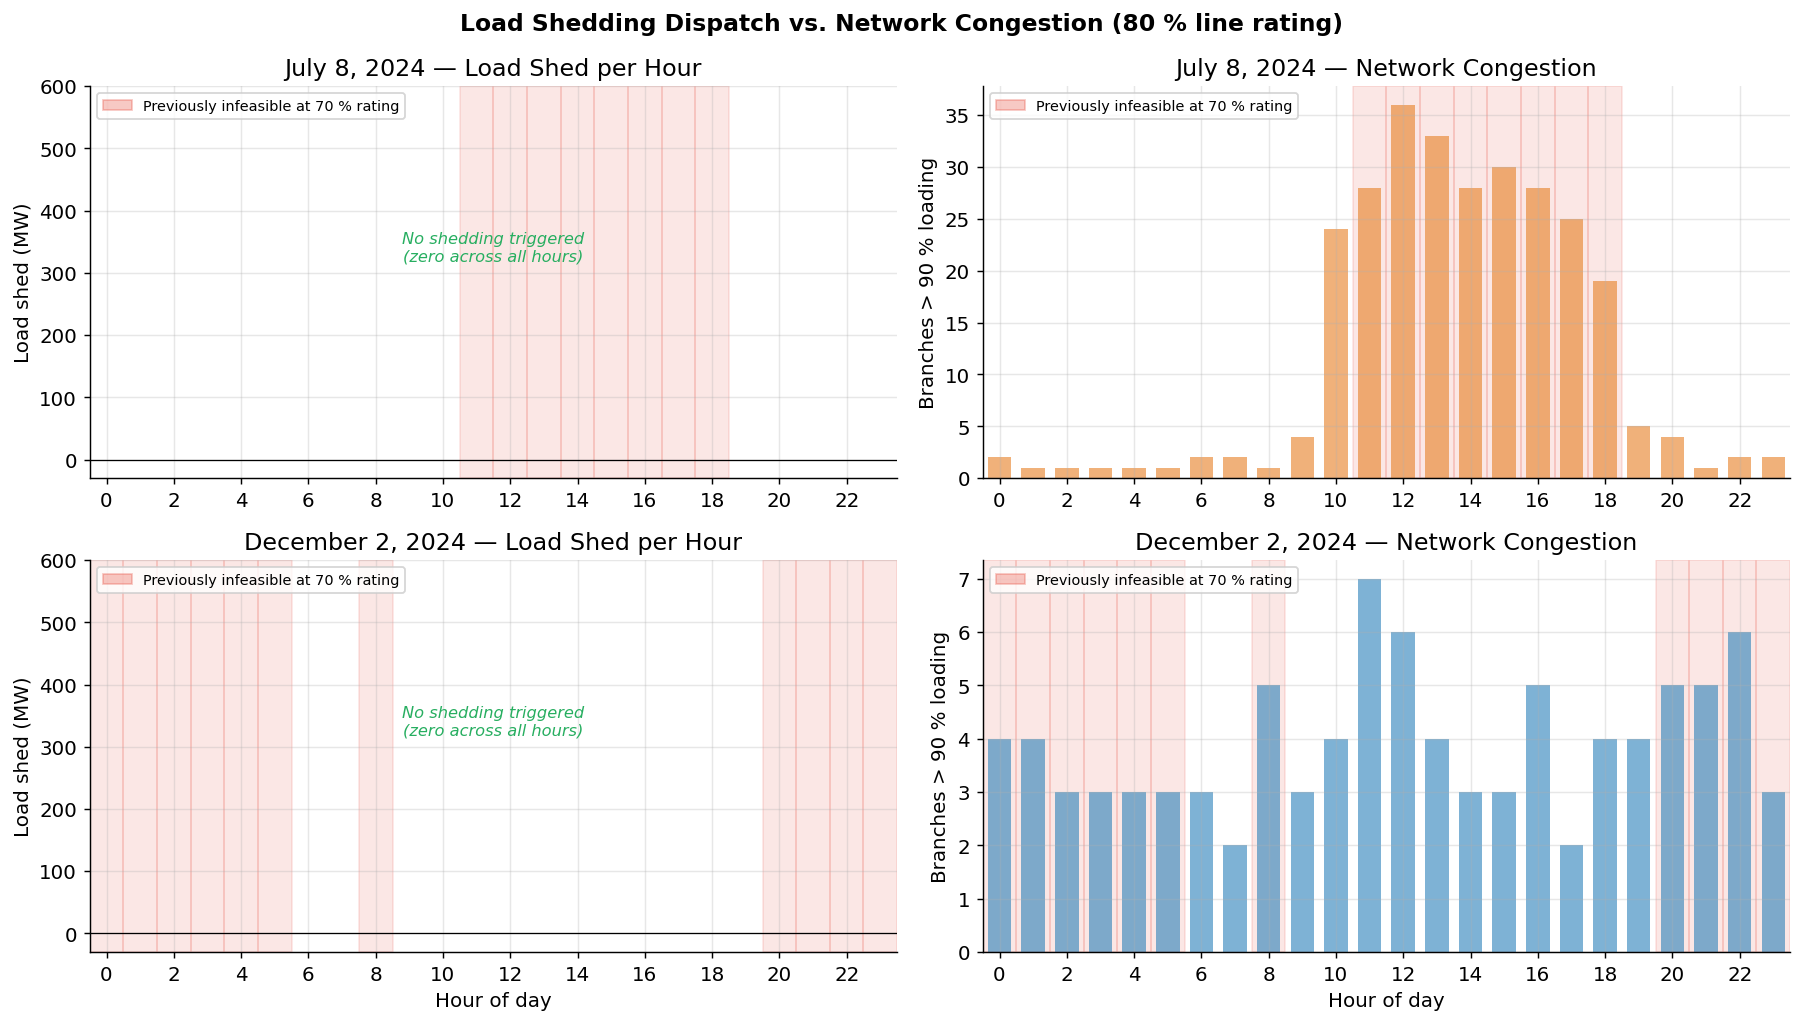

Saved: results/load_shedding_hourly.png


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

RESULTS = Path('results')
summary_df = pd.read_csv(RESULTS / 'summary.csv')
branch_df  = pd.read_csv(RESULTS / 'branch_flows.csv')

congested = (branch_df[branch_df['loading_pct'] > 90]
             .groupby(['date', 'hour']).size()
             .reset_index(name='n_congested'))
summary_df = summary_df.merge(congested, on=['date', 'hour'], how='left')
summary_df['n_congested']  = summary_df['n_congested'].fillna(0).astype(int)
summary_df['load_shed_mw'] = summary_df['load_shed_mw'].fillna(0).clip(lower=0)

infeasible_70 = {
    '2024-07-08': list(range(11, 19)),
    '2024-12-02': [0, 1, 2, 3, 4, 5, 8, 20, 21, 22, 23],
}
DATES  = ['2024-07-08', '2024-12-02']
LABELS = {'2024-07-08': 'July 8, 2024', '2024-12-02': 'December 2, 2024'}
CLRS   = {'2024-07-08': '#e67e22',      '2024-12-02': '#2980b9'}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Load Shedding Dispatch vs. Network Congestion (80 % line rating)',
             fontsize=13, fontweight='bold')

for row_i, date in enumerate(DATES):
    df     = summary_df[summary_df['date'] == date].sort_values('hour')
    hours  = df['hour'].values
    shed   = df['load_shed_mw'].values
    cong   = df['n_congested'].values
    infeas = infeasible_70.get(date, [])
    colour = CLRS[date]
    red_patch = mpatches.Patch(color='#e74c3c', alpha=0.30,
                               label='Previously infeasible at 70 % rating')

    ax_l = axes[row_i, 0]
    ax_l.bar(hours, shed, color=colour, alpha=0.85, width=0.7)
    for h in infeas:
        ax_l.axvspan(h - 0.5, h + 0.5, color='#e74c3c', alpha=0.13, zorder=0)
    ax_l.axhline(0, color='black', linewidth=0.7)
    ax_l.set_xlim(-0.5, 23.5)
    ax_l.set_ylim(-30, 600)
    ax_l.set_ylabel('Load shed (MW)')
    ax_l.set_title(f'{LABELS[date]} — Load Shed per Hour')
    ax_l.set_xticks(range(0, 24, 2))
    ax_l.text(11.5, 320, 'No shedding triggered\n(zero across all hours)',
              ha='center', fontsize=9, color='#27ae60', fontstyle='italic')
    ax_l.legend(handles=[red_patch], fontsize=8, loc='upper left')

    ax_r = axes[row_i, 1]
    ax_r.bar(hours, cong, color=colour, alpha=0.60, width=0.7)
    for h in infeas:
        ax_r.axvspan(h - 0.5, h + 0.5, color='#e74c3c', alpha=0.13, zorder=0)
    ax_r.set_xlim(-0.5, 23.5)
    ax_r.set_ylabel('Branches > 90 % loading')
    ax_r.set_title(f'{LABELS[date]} — Network Congestion')
    ax_r.set_xticks(range(0, 24, 2))
    ax_r.legend(handles=[red_patch], fontsize=8, loc='upper left')

for ax in axes[1]:
    ax.set_xlabel('Hour of day')

plt.tight_layout()
plt.savefig(RESULTS / 'load_shedding_hourly.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/load_shedding_hourly.png')

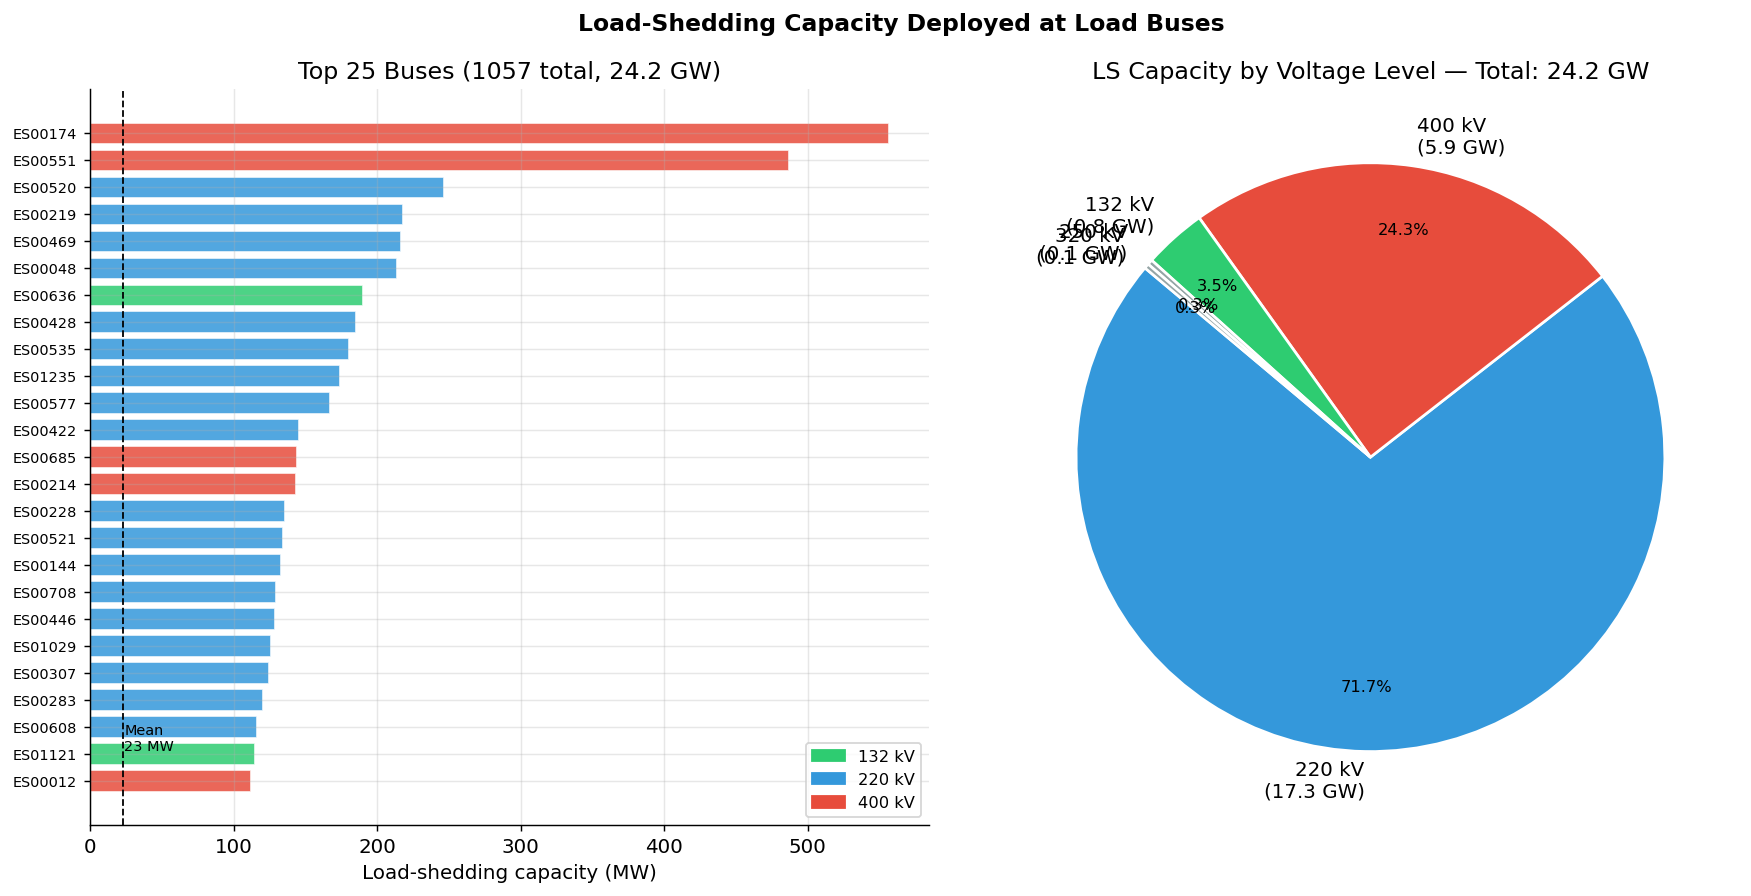

LS generators: 1057  |  total capacity: 24201 MW


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

RESULTS = Path('results')
gen_df    = pd.read_csv(RESULTS / 'gen_dispatch.csv')
buses_geo = pd.read_csv('Data/Bus_Data.csv', encoding='utf-8-sig')
buses_geo = buses_geo.rename(columns={'x': 'lon', 'y': 'lat'})

ls_cap = (gen_df[gen_df['fuel'] == 'LoadShed']
          .groupby(['bus_i', 'unit_name'])
          .agg(capacity_mw=('capacity_mw', 'first'))
          .reset_index())
ls_cap['bus_id'] = ls_cap['unit_name'].str[3:]
ls_cap = ls_cap.merge(buses_geo[['bus_id', 'lat', 'lon', 'voltage']],
                      on='bus_id', how='left').dropna(subset=['lat', 'lon', 'voltage'])
ls_cap['voltage'] = ls_cap['voltage'].astype(int)

VKV_COLORS = {400: '#e74c3c', 220: '#3498db', 132: '#2ecc71', 110: '#9b59b6', 66: '#f39c12'}

top25      = ls_cap.nlargest(25, 'capacity_mw').sort_values('capacity_mw')
bar_colors = [VKV_COLORS.get(v, '#95a5a6') for v in top25['voltage']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle('Load-Shedding Capacity Deployed at Load Buses', fontsize=13, fontweight='bold')

ax1.barh(range(len(top25)), top25['capacity_mw'], color=bar_colors,
         alpha=0.85, edgecolor='white')
ax1.set_yticks(range(len(top25)))
ax1.set_yticklabels(top25['bus_id'], fontsize=8)
mean_cap = ls_cap['capacity_mw'].mean()
ax1.axvline(mean_cap, color='black', linestyle='--', linewidth=1)
ax1.text(mean_cap + 1, 1, f'Mean\n{mean_cap:.0f} MW', fontsize=8, va='bottom')
ax1.set_xlabel('Load-shedding capacity (MW)')
ax1.set_title(f'Top 25 Buses ({len(ls_cap)} total, '
              f'{ls_cap["capacity_mw"].sum()/1e3:.1f} GW)')
present_kvs = sorted(set(top25['voltage'].unique()) & set(VKV_COLORS))
ax1.legend(handles=[mpatches.Patch(color=VKV_COLORS[v], label=f'{v} kV')
                    for v in present_kvs], fontsize=9)

vkv_totals = ls_cap.groupby('voltage')['capacity_mw'].sum().sort_values(ascending=False)
pie_colors = [VKV_COLORS.get(v, '#95a5a6') for v in vkv_totals.index]
wedges, texts, autotexts = ax2.pie(
    vkv_totals.values,
    labels=[f'{v} kV\n({tot/1e3:.1f} GW)' for v, tot in vkv_totals.items()],
    colors=pie_colors, autopct='%1.1f%%', startangle=140,
    pctdistance=0.78, wedgeprops=dict(edgecolor='white', linewidth=1.5))
for at in autotexts:
    at.set_fontsize(9)
ax2.set_title(f'LS Capacity by Voltage Level — Total: {ls_cap["capacity_mw"].sum()/1e3:.1f} GW')

plt.tight_layout()
plt.savefig(RESULTS / 'load_shedding_capacity.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'LS generators: {len(ls_cap)}  |  total capacity: {ls_cap["capacity_mw"].sum():.0f} MW')

In [27]:
import folium
import pandas as pd
import numpy as np
from pathlib import Path
import webbrowser

RESULTS = Path('results')
gen_df    = pd.read_csv(RESULTS / 'gen_dispatch.csv')
buses_geo = pd.read_csv('Data/Bus_Data.csv', encoding='utf-8-sig')
buses_geo = buses_geo.rename(columns={'x': 'lon', 'y': 'lat'})

ls_cap = (gen_df[gen_df['fuel'] == 'LoadShed']
          .groupby(['bus_i', 'unit_name'])
          .agg(capacity_mw=('capacity_mw', 'first'),
               dispatch_mw=('dispatch_mw', 'mean'))
          .reset_index())
ls_cap['bus_id']      = ls_cap['unit_name'].str[3:]
ls_cap['dispatch_mw'] = ls_cap['dispatch_mw'].clip(lower=0)
ls_cap = ls_cap.merge(buses_geo[['bus_id', 'lat', 'lon', 'voltage']],
                      on='bus_id', how='left').dropna(subset=['lat', 'lon'])

VKV_HEX = {400: '#e74c3c', 220: '#3498db', 132: '#2ecc71', 110: '#9b59b6', 66: '#f39c12'}

m = folium.Map(location=[40.0, -3.5], zoom_start=6,
               tiles='CartoDB positron', prefer_canvas=True)

for _, row in ls_cap.iterrows():
    voltage = int(row['voltage']) if not pd.isna(row['voltage']) else 220
    colour  = VKV_HEX.get(voltage, '#95a5a6')
    radius  = max(3, np.sqrt(float(row['capacity_mw'])) * 0.45)
    shed_lbl = ('<b style="color:#e74c3c">YES</b>'
                if float(row['dispatch_mw']) > 0.01
                else '<span style="color:#27ae60">No</span>')
    popup_html = (f"<b>{row['bus_id']}</b><br>"
                  f"Voltage: {voltage} kV<br>"
                  f"LS capacity: <b>{float(row['capacity_mw']):.1f} MW</b><br>"
                  f"Shedding dispatched: {shed_lbl}")
    folium.CircleMarker(
        location=[float(row['lat']), float(row['lon'])],
        radius=radius, color=colour, fill=True,
        fill_color=colour, fill_opacity=0.50,
        popup=folium.Popup(popup_html, max_width=220),
        tooltip=f"{row['bus_id']} — {float(row['capacity_mw']):.0f} MW LS",
    ).add_to(m)

legend_html = (
    '<div style="position:fixed;bottom:30px;left:30px;z-index:1000;background:white;'
    'padding:10px 14px;border-radius:6px;box-shadow:0 2px 6px rgba(0,0,0,.3);'
    'font-size:12px;line-height:1.9;">'
    '<b>Load-shedding capacity</b><br>'
    '<span style="color:#e74c3c">&#9679;</span> 400 kV &nbsp;'
    '<span style="color:#3498db">&#9679;</span> 220 kV &nbsp;'
    '<span style="color:#2ecc71">&#9679;</span> 132 kV<br>'
    '<span style="color:#9b59b6">&#9679;</span> 110 kV &nbsp;'
    '<span style="color:#f39c12">&#9679;</span> 66 kV<br>'
    '<i>Circle area &prop; capacity (MW)</i><br>'
    '<span style="color:#27ae60">&#10003;</span>'
    ' <i>No shedding dispatched (80 % rating)</i>'
    '</div>')
m.get_root().html.add_child(folium.Element(legend_html))

out_path = RESULTS / 'load_shedding_map.html'
m.save(out_path)
webbrowser.open(out_path.resolve().as_uri(), new=2)
print(f'Map saved: {out_path}')

Map saved: results\load_shedding_map.html
